In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import polars as pl
import polars.selectors as selectors

from src.config import RAW_TRAIN_DATA_DIR, TARGET_PATH, USED_DATASET_PATH

In [3]:
data_lazy = (
    pl.scan_parquet(RAW_TRAIN_DATA_DIR)
    .with_columns(
        selectors.integer().exclude("id").cast(pl.Int16),
        pl.col("id").cast(pl.Int32),
        selectors.float().cast(pl.Float16),
    )
)

target_lazy = pl.scan_csv(
    TARGET_PATH,
    schema_overrides={"id": pl.Int32, "flag": pl.Int8},
)

data = (
    data_lazy
    .join(target_lazy, on="id", how="inner")
    .collect(engine="streaming")
    .sample(n=2_000_000, seed=0)
)

In [4]:
data = data.drop(["pre_fterm", "pre_till_fclose", "fclose_flag"])

- `pre_fterm`: True duration. Known only if the loan is already closed → leakage.
- `pre_till_fclose`:Remaining days until the true end. Needs to know the real closure date → leakage.
- `fclose_flag`: Indicates if the loan is already closed at the collect.

**Decision:** Drop those columns

In [5]:
data.write_parquet(USED_DATASET_PATH)

# EXPLORATORY DATA ANALYSIS

## OVERVIEW

- target: `flag`

Shape: 2 000 000, 62

In [6]:
data.shape

(2000000, 59)

## Description

In [7]:
data.describe()

statistic,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,flag
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.5466e6,7.0445195,9.3609705,8.22429,8.372251,7.1454615,9.6783725,2.363823,2.996637,0.0,2.005674,4.61566,5.97461,15.873246,5.0013975,3.9998385,8.003395,0.9190225,0.8322565,0.9573685,0.9754115,0.975987,13.833659,2.211901,15.685595,0.69844,0.930235,0.855747,0.164335,0.380172,0.5187745,0.6484295,0.7817555,0.913616,1.073882,1.2287425,1.342532,1.450957,1.578716,2.709618,1.8435725,1.9661315,2.0292445,2.078375,2.123287,2.1653425,2.209632,2.250326,3.2847245,2.3168,2.3481485,2.3817615,3.5308895,1.0343065,2.693616,3.519668,1.001766,0.1490615,0.0336195
"""std""",867809.94115,5.394488,5.773329,4.712775,5.324814,5.151655,5.825083,1.308982,0.708964,0.0,0.282482,3.308328,0.388738,1.172049,0.073726,0.021874,0.149434,0.272801,0.373638,0.202025,0.154867,0.153089,4.382551,0.859547,3.983204,0.458935,0.254751,0.351346,0.629509,0.933221,1.083991,1.191126,1.278361,1.346808,1.408606,1.448511,1.467325,1.476865,1.477715,1.466814,1.44338,1.409679,1.387932,1.368975,1.34963,1.330098,1.307835,1.285508,1.265349,1.245453,1.225024,1.201855,1.079884,0.306334,0.499292,1.037431,0.049213,0.356149,0.180248
"""min""",0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",796484.0,3.0,4.0,4.0,4.0,2.0,5.0,2.0,3.0,0.0,2.0,2.0,6.0,16.0,5.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,15.0,2.0,17.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,3.0,3.0,3.0,4.0,1.0,2.0,3.0,1.0,0.0,0.0
"""50%""",1.569881e6,6.0,9.0,9.0,8.0,7.0,10.0,2.0,3.0,0.0,2.0,4.0,6.0,16.0,5.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,16.0,2.0,17.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,1.0,3.0,4.0,1.0,0.0,0.0
"""75%""",2.304694e6,10.0,14.0,12.0,14.0,12.0,15.0,2.0,3.0,0.0,2.0,7.0,6.0,16.0,5.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,16.0,2.0,17.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,1.0,3.0,4.0,1.0,0.0,0.0
"""max""",2.999996e6,51.0,19.0,17.0,17.0,16.0,19.0,6.0,5.0,0.0,3.0,13.0,16.0,18.0,9.0,4.0,19.0,1.0,1.0,1.0,1.0,1.0,19.0,19.0,19.0,1.0,1.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,6.0,6.0,7.0,3.0,1.0,1.0


In [8]:
data.glimpse()

Rows: 2000000
Columns: 59
$ id                            <i32> 2920474, 656099, 587837, 146995, 1035922, 55184, 2184557, 2102845, 2931252, 171890
$ rn                            <i16> 9, 1, 1, 4, 4, 2, 4, 2, 16, 5
$ pre_since_opened              <i16> 6, 0, 8, 18, 18, 12, 10, 3, 5, 17
$ pre_since_confirmed           <i16> 14, 9, 7, 8, 9, 9, 4, 9, 13, 12
$ pre_pterm                     <i16> 17, 8, 8, 11, 2, 4, 13, 2, 2, 2
$ pre_till_pclose               <i16> 11, 6, 4, 7, 16, 1, 6, 7, 2, 2
$ pre_loans_credit_limit        <i16> 15, 18, 5, 0, 14, 16, 3, 12, 16, 16
$ pre_loans_next_pay_summ       <i16> 2, 6, 2, 2, 0, 4, 2, 6, 2, 4
$ pre_loans_outstanding         <i16> 3, 3, 3, 1, 3, 2, 3, 3, 3, 3
$ pre_loans_total_overdue       <i16> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
$ pre_loans_max_overdue_sum     <i16> 2, 2, 2, 1, 1, 2, 2, 2, 3, 2
$ pre_loans_credit_cost_rate    <i16> 2, 4, 4, 4, 1, 5, 2, 2, 4, 5
$ pre_loans5                    <i16> 6, 6, 6, 6, 6, 6, 6, 6, 6, 6
$ pre_loans530              

## Target distribution
- 0: 96.637%
- 1: 3.363%

In [9]:
target_dist = data.select(
    [
        (pl.col("flag").eq(0).sum() / pl.col("flag").len()).alias("0 flag"),
        (pl.col("flag").eq(1).sum() / pl.col("flag").len()).alias("1 flag"),
    ]
)

target_dist

0 flag,1 flag
f64,f64
0.9663805,0.0336195


## Missing value

No missing values

In [10]:
missing_dataset = data.select(
    (pl.all().exclude(["id", "flag"]).is_nan().sum() / len(data))
)
missing_dataset

rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Data visualization

In [11]:
categorical_features = [f"enc_paym_{i}" for i in range(25)]
categorical_features.extend(
    [
        "is_zero_loans5",
        "is_zero_loans530",
        "is_zero_loans3060",
        "is_zero_loans6090",
        "is_zero_loans90",
        "is_zero_util",
        "is_zero_over2limit",
        "is_zero_maxover2limit",
        "enc_loans_account_holder_type",
        "enc_loans_credit_status",
        "enc_loans_credit_type",
        "enc_loans_account_cur",
        "pclose_flag",
    ]
)

In [12]:
numerical_features = [
    "rn",
    "pre_since_opened",
    "pre_since_confirmed",
    "pre_pterm",
    "pre_till_pclose",
    "pre_loans_credit_limit",
    "pre_loans_next_pay_summ",
    "pre_loans_outstanding",
    "pre_loans_total_overdue",
    "pre_loans_max_overdue_sum",
    "pre_loans_credit_cost_rate"
]

In [13]:
def feature_distribution(df: pd.DataFrame, features: list, categorical: bool):
    df = df.select(
        pl.col(features)
    ).to_pandas()

    if categorical:
        for feature in features:
            plt.figure(figsize=(10, 5))
            plt.title(feature)
            sb.countplot(data=df, x=feature)
            plt.xticks(rotation=45)
            plt.show()
    else:
        for feature in features:
            plt.figure(figsize=(10, 5))
            plt.title(feature)
            sb.histplot(df[feature], kde=True)
            plt.show()


### Numerical features
- The `rn` seems show me that the more the loan is older the more we have customers
- the `pre_since_confirmed` seems have a main value
- `pre_pterm`: has 2 main values (maybe the client prefer theses durations?)
- `pre_till_pclose`: most customers seem closed her loan at a certain time before the planed closure
- `pre_till_fclose`: has also a main value occurences
- `pre_loans_credit_cost_rate`: 2 main values occur
- `pre_loans_next_pay_summ` and `pre_loans_outstanding`, `pre_loans_total_overdue` seem constraint between a few values(Is it normal or another thing?)
- `pre_loans_credit_cost_rate`: has 2 predominant values
- `pre_loans_max_overdue_sum` is not pertinent we must have to drop it

**Observations:** Some features seem restraint in a few values. If it's a standard we can try to convert it into categorical value, and it seems have a lot of outlier. We can have to manage that(winsorizer or robustscaler).

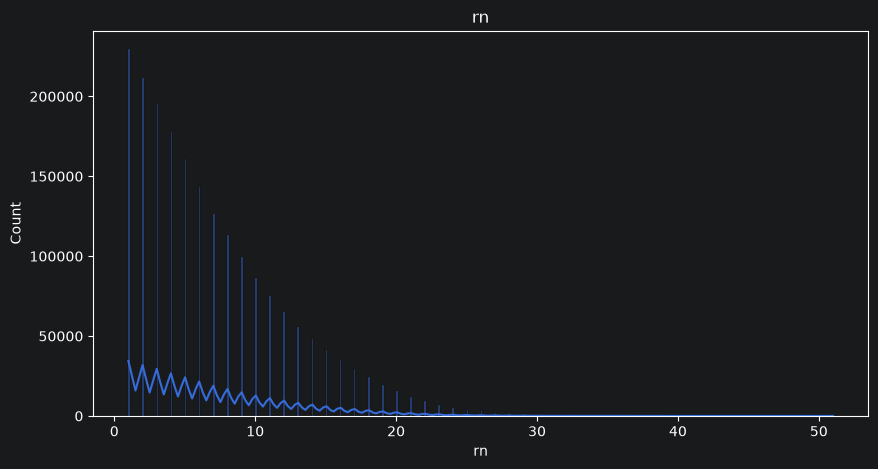

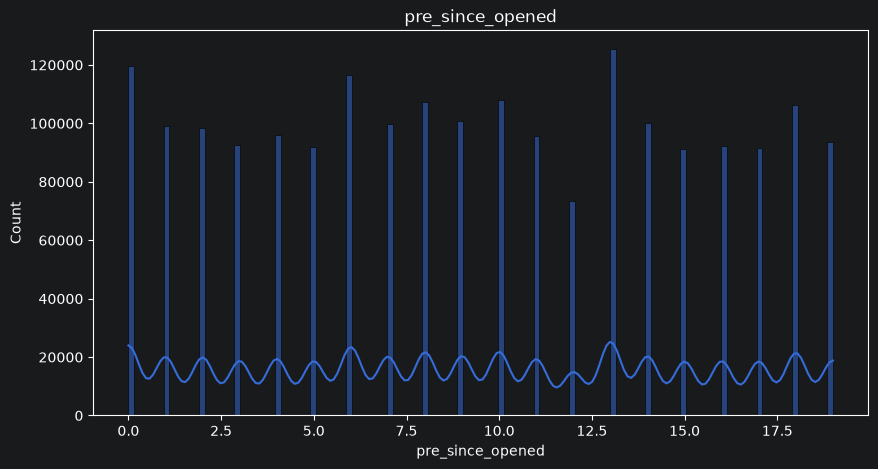

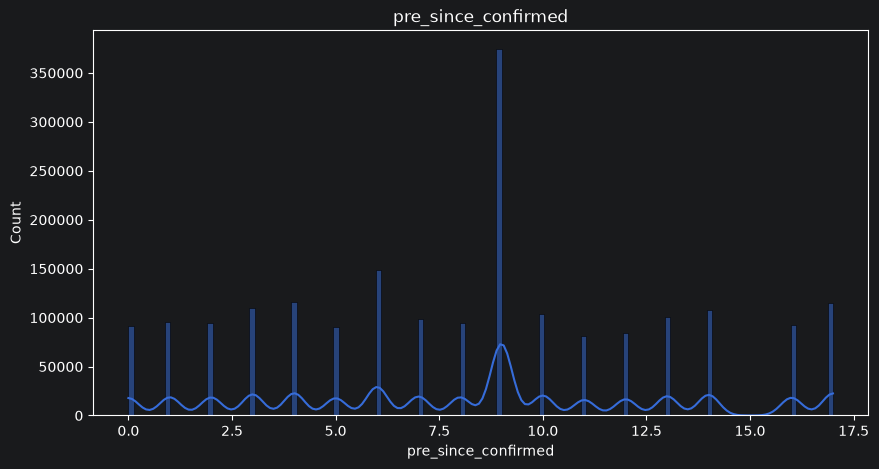

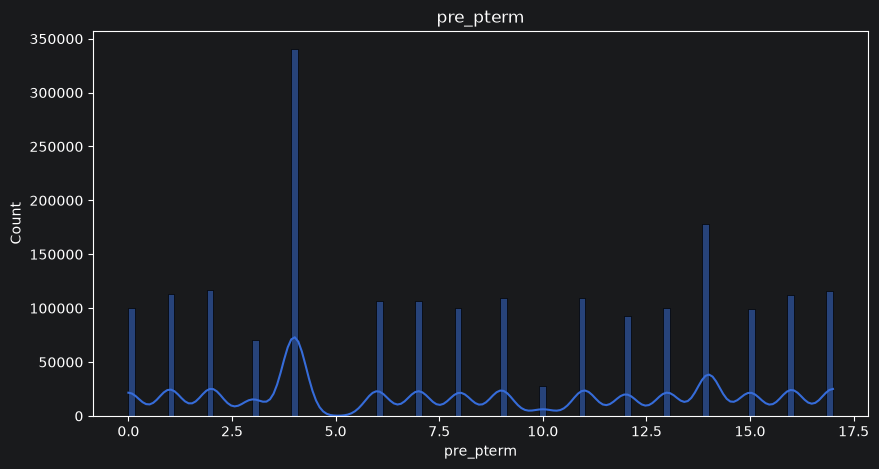

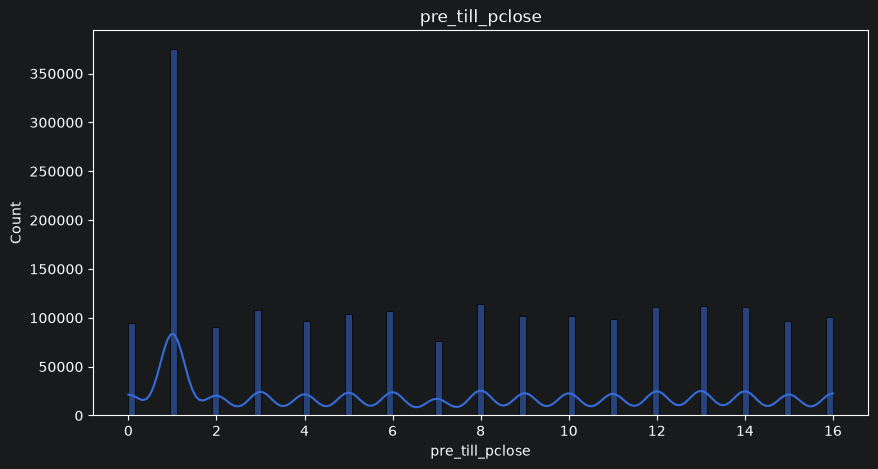

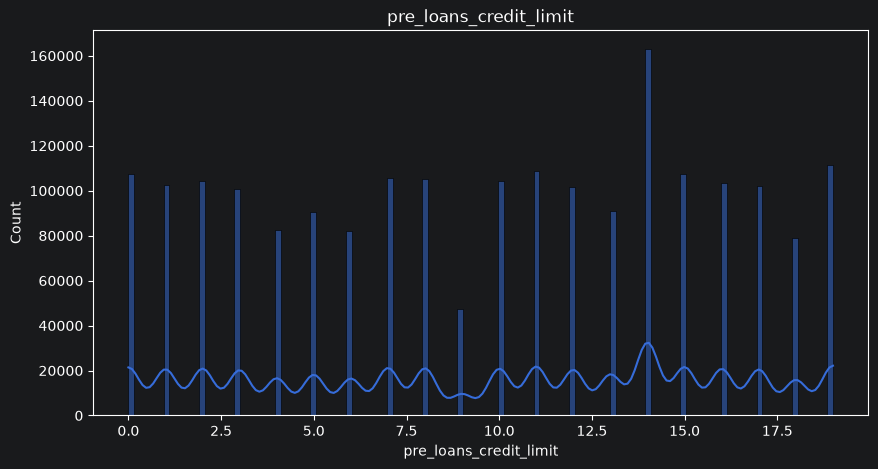

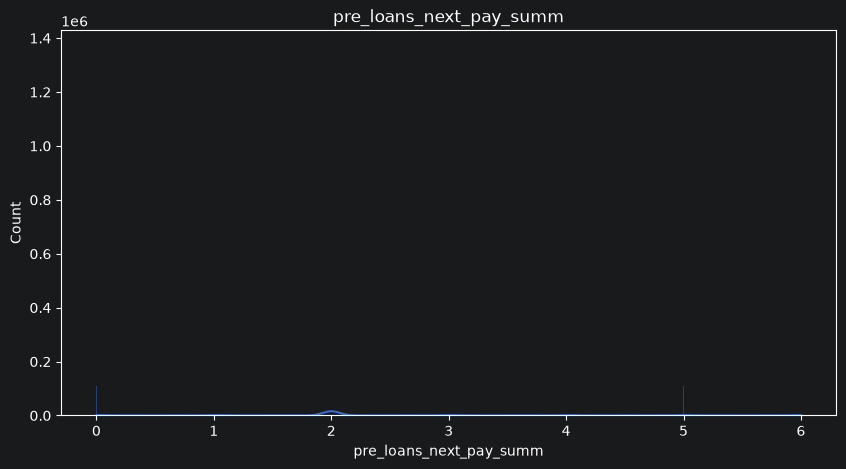

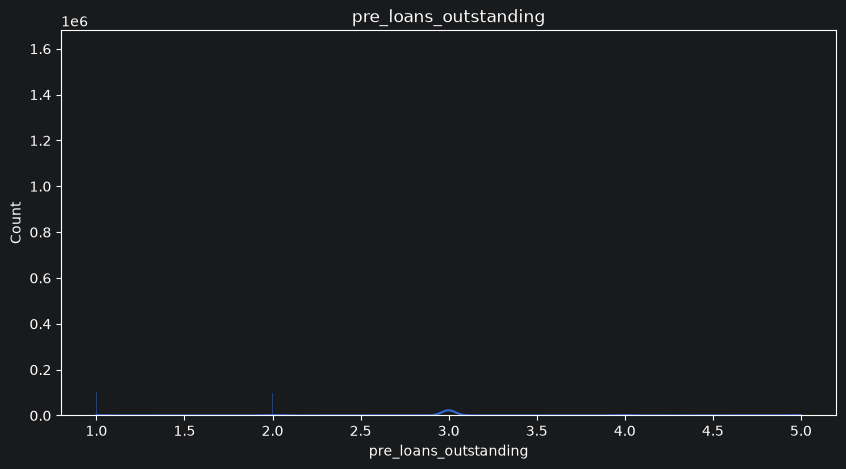

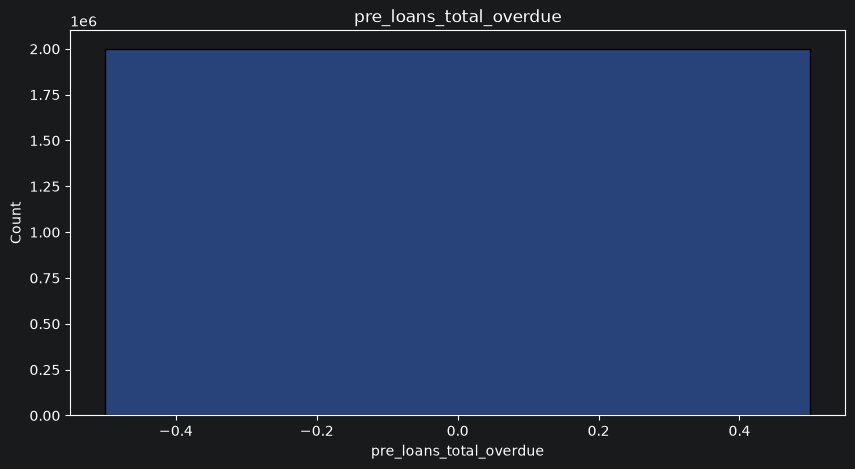

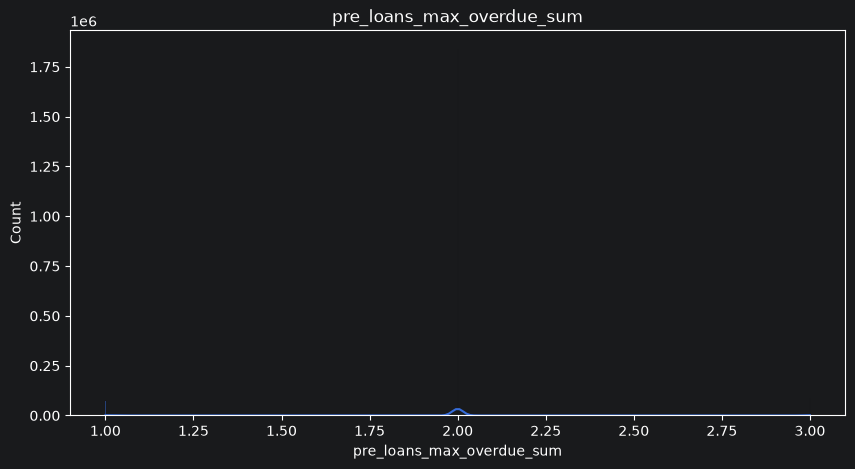

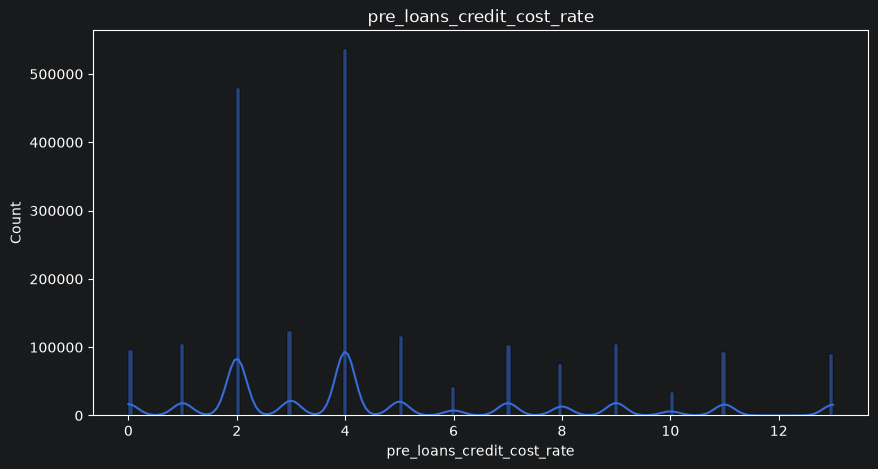

In [14]:
feature_distribution(df= data, features=numerical_features, categorical=False)

### Categorical features

Most of data are very imbalanced

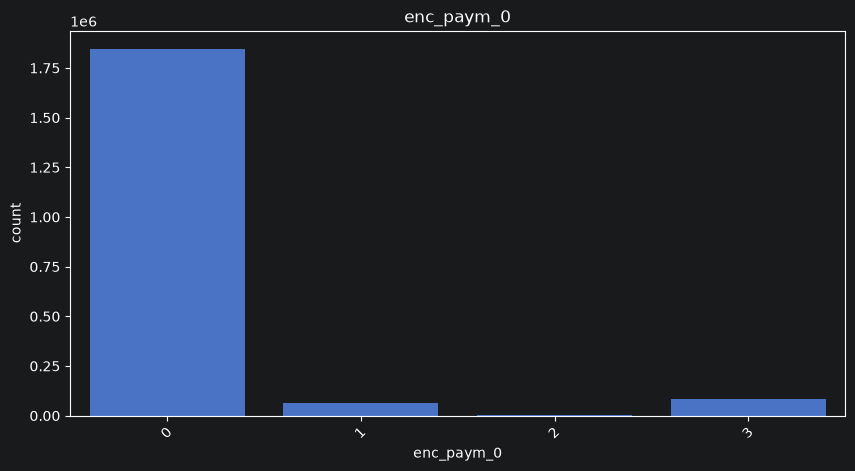

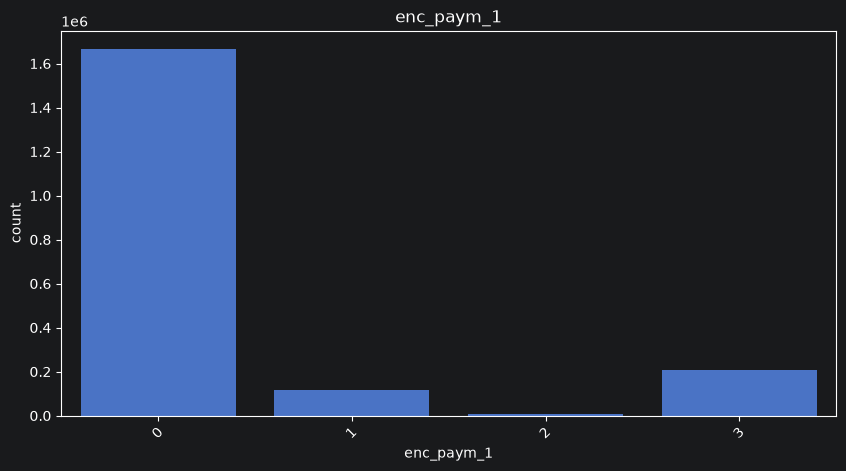

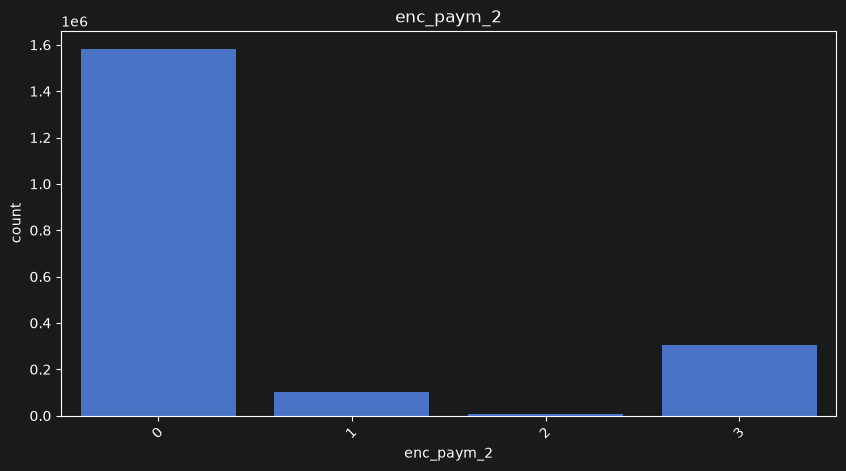

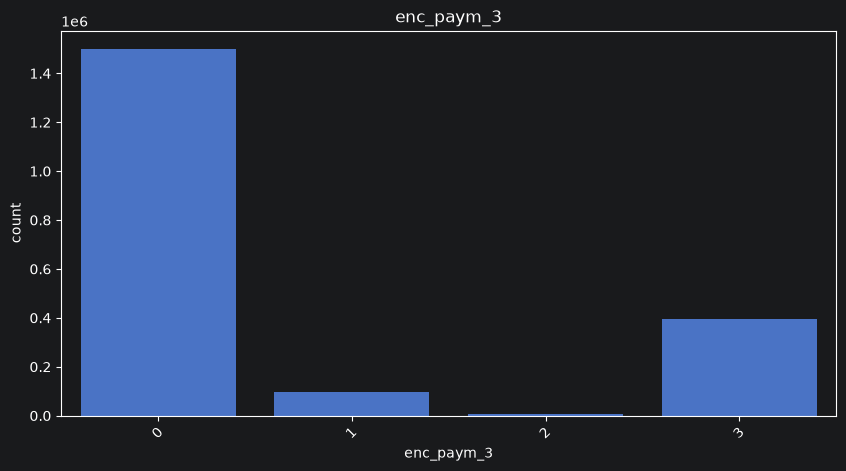

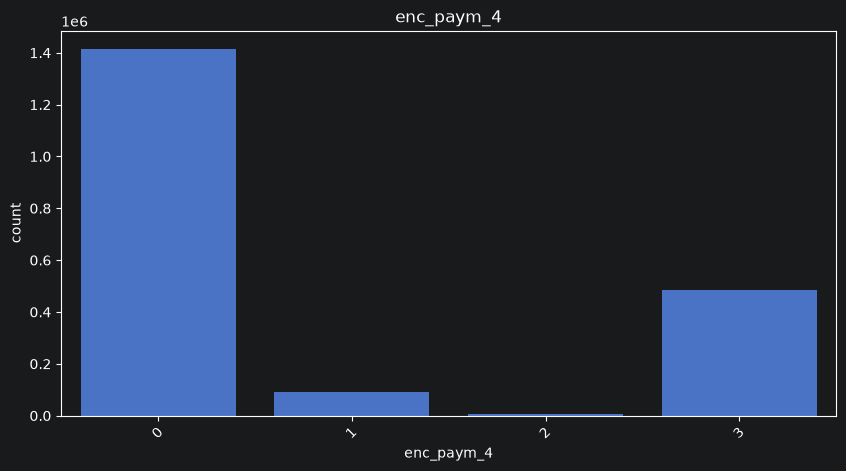

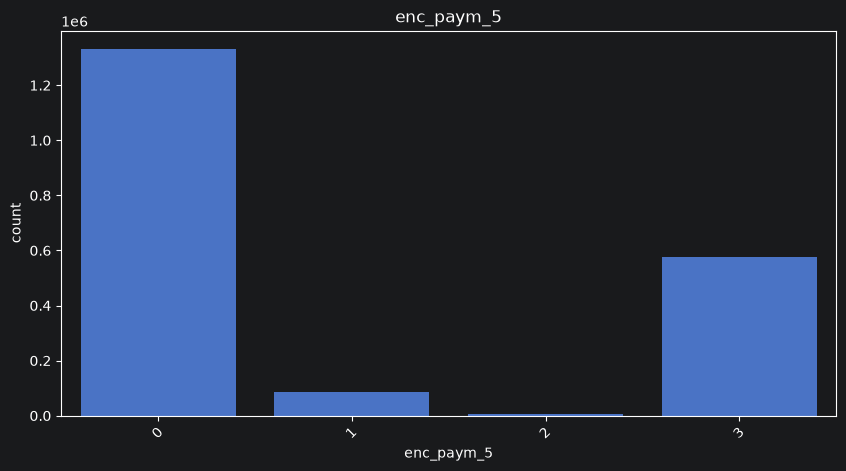

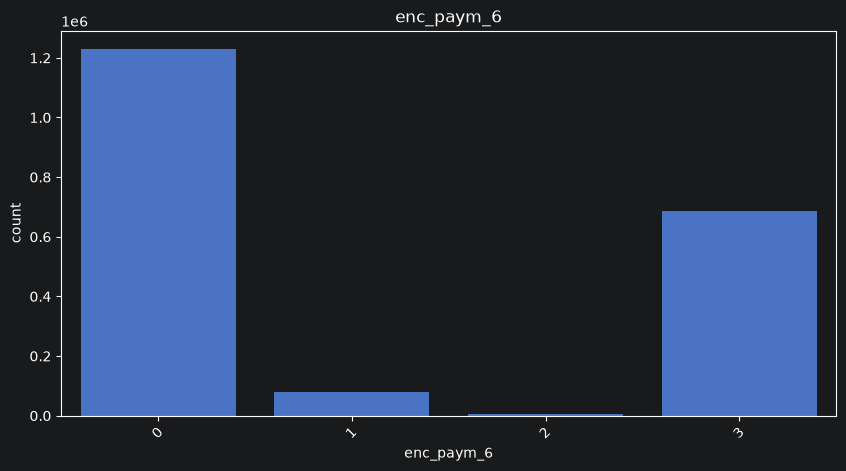

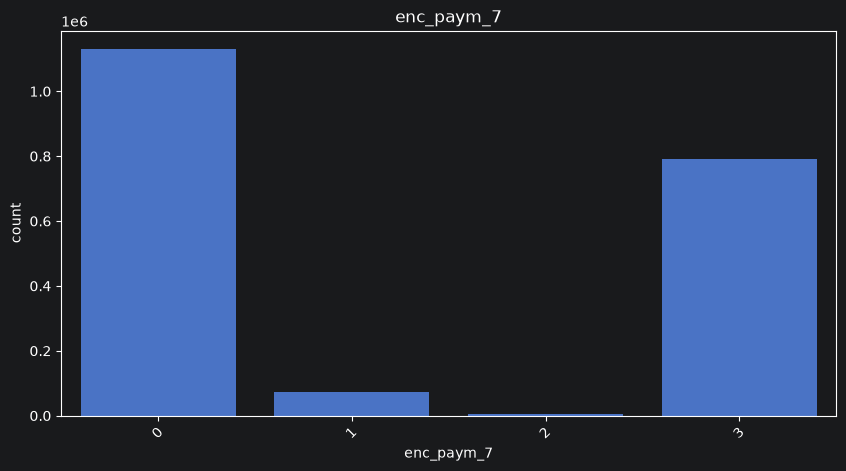

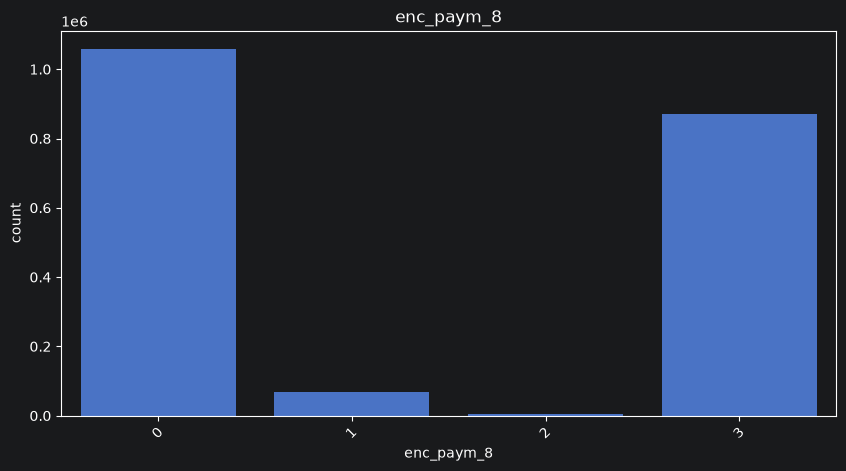

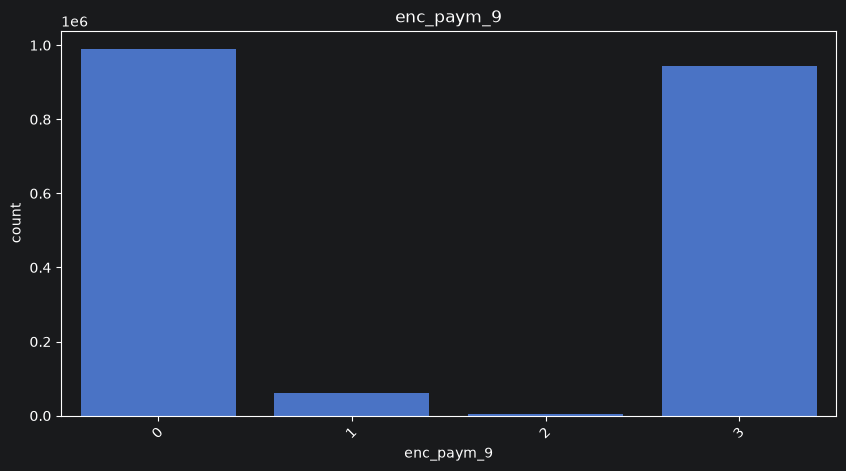

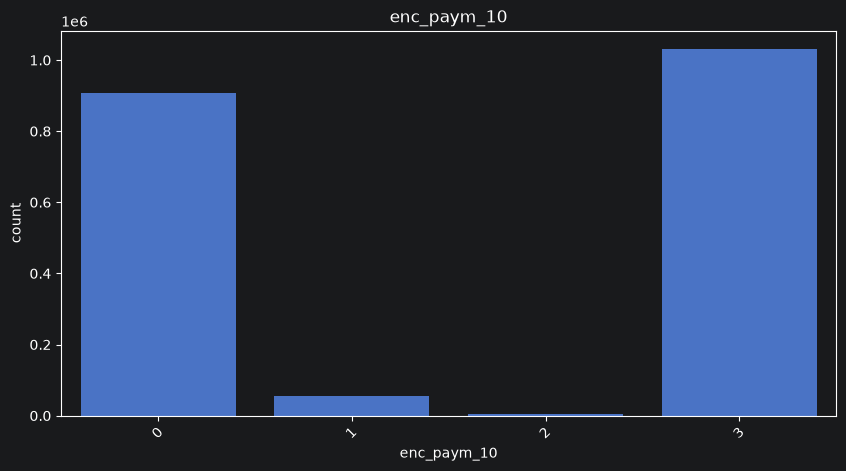

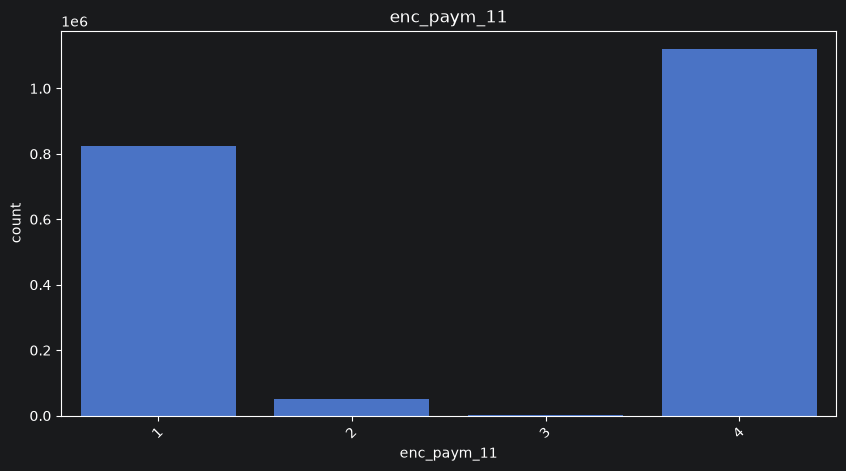

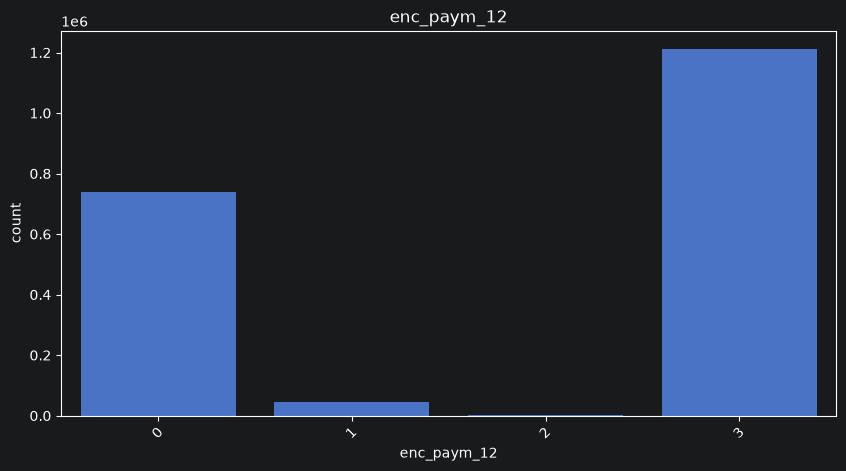

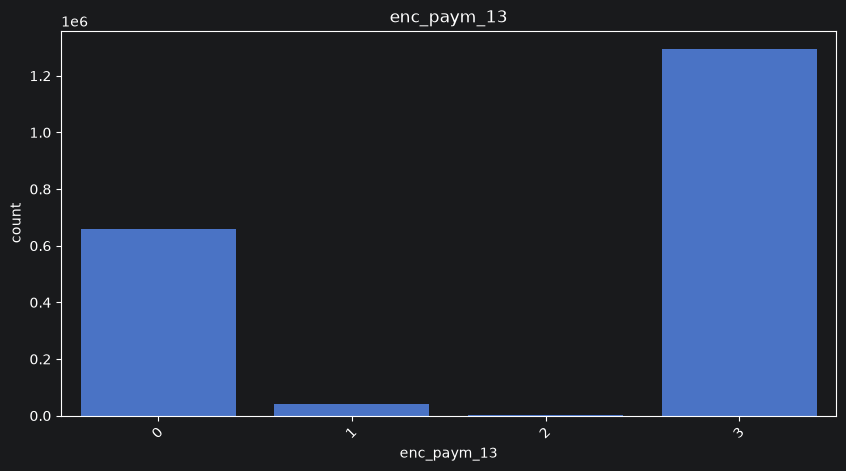

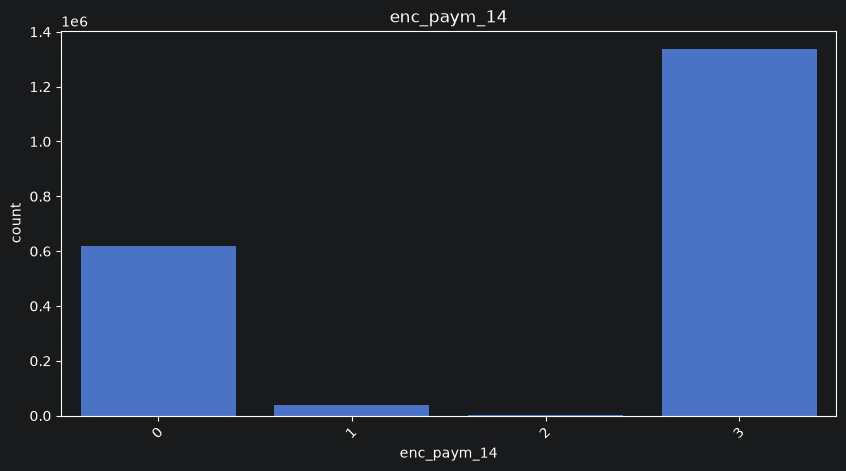

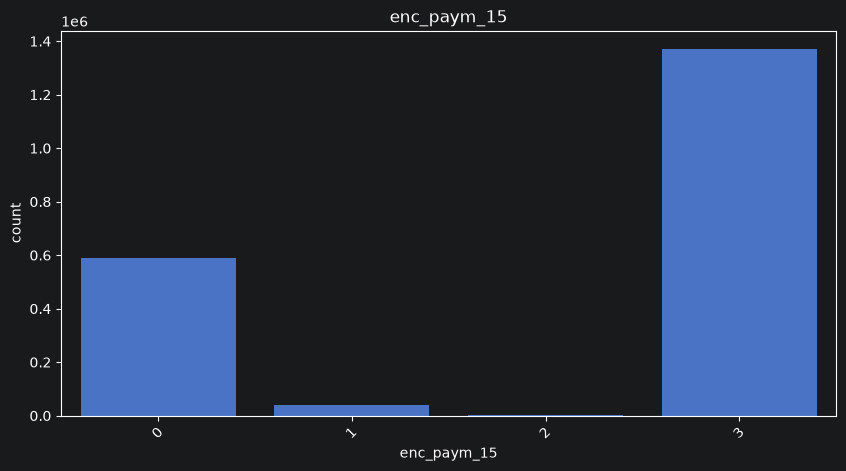

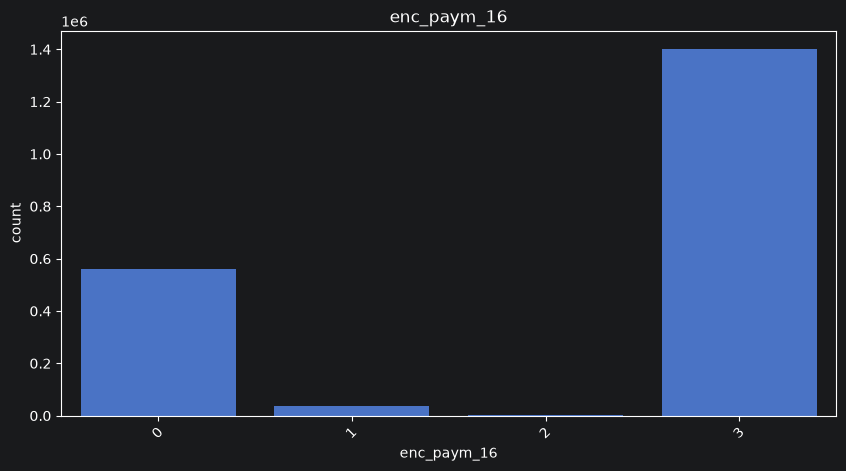

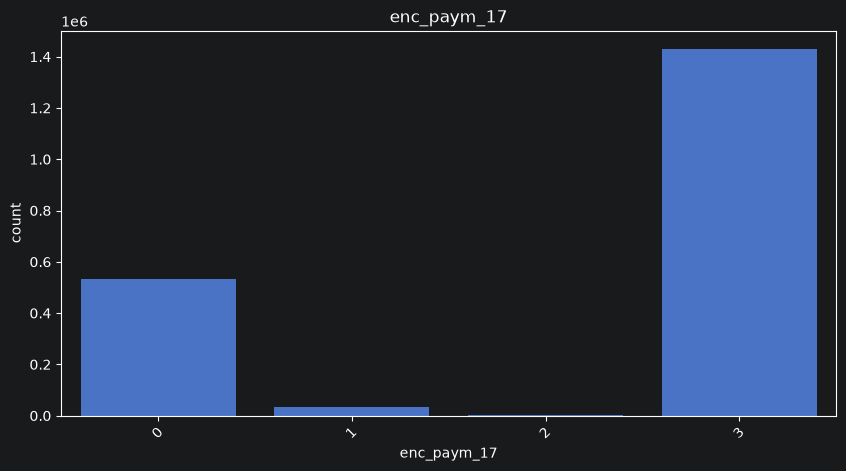

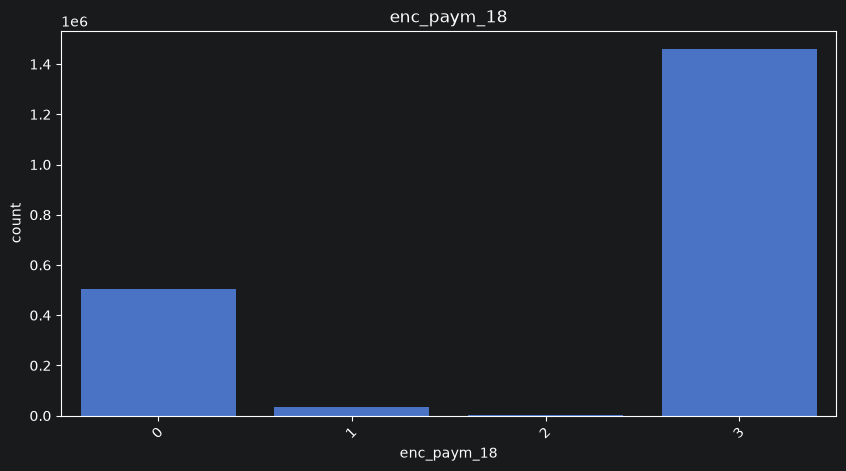

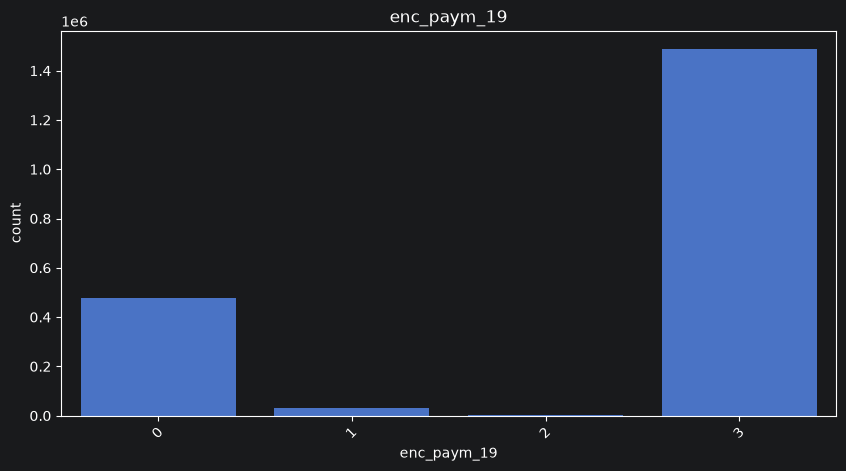

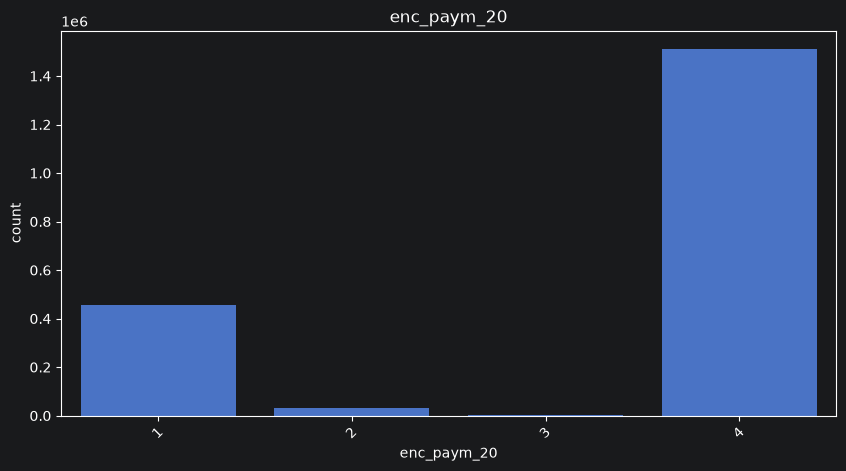

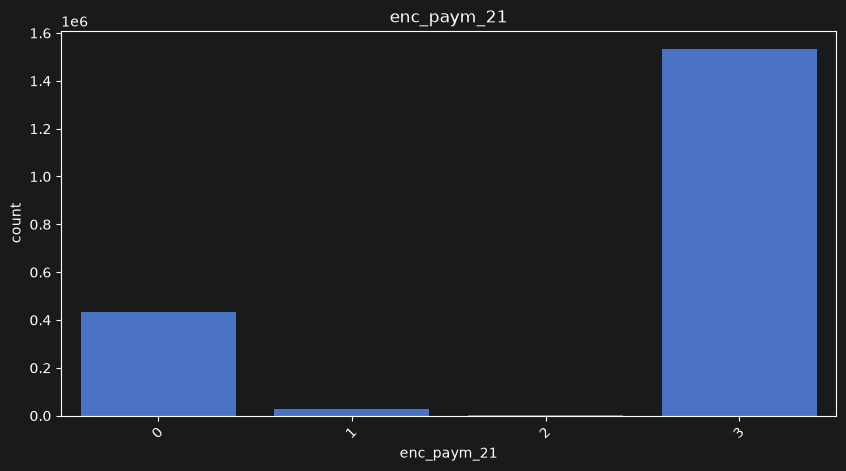

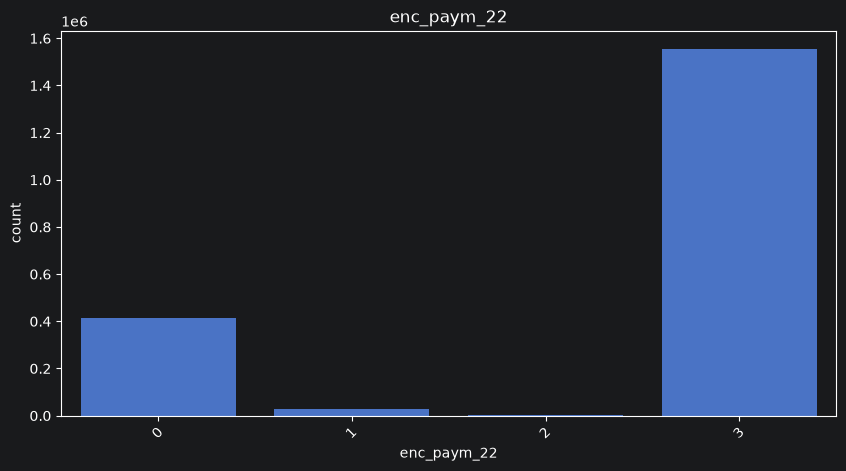

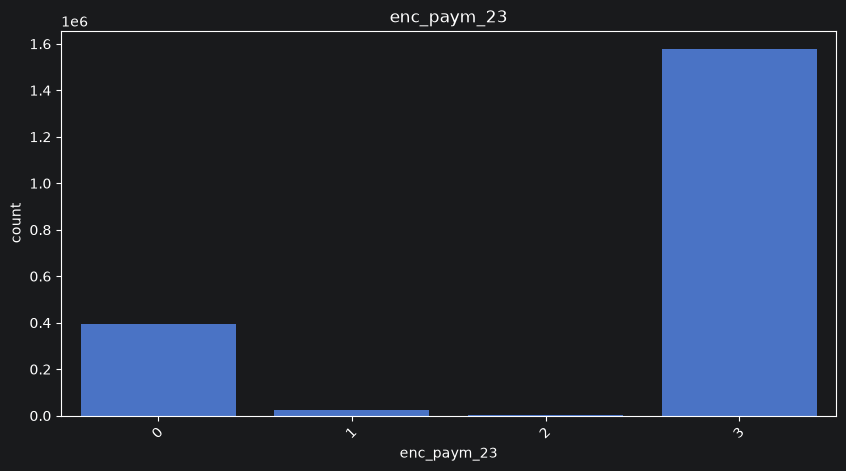

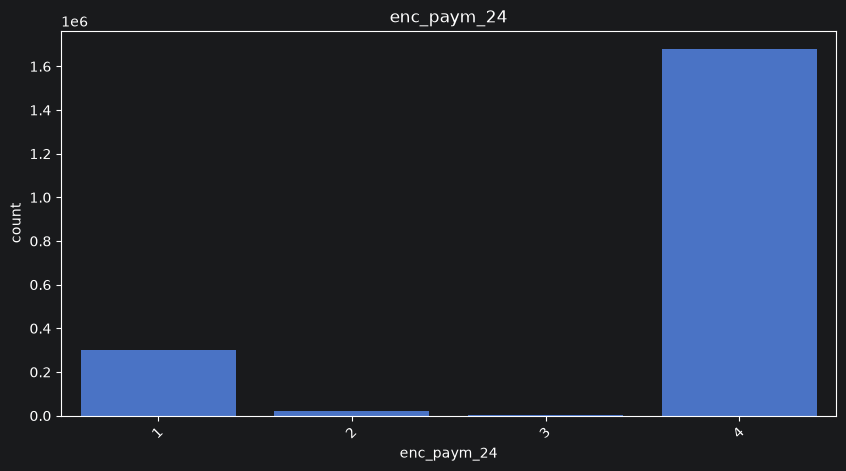

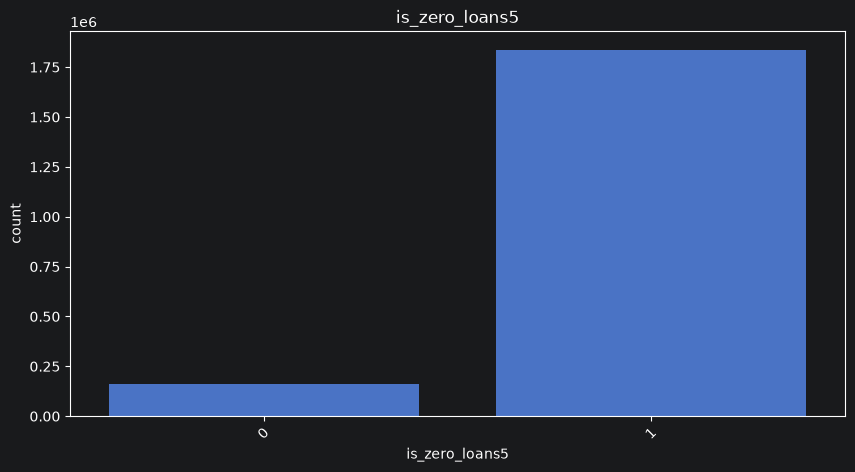

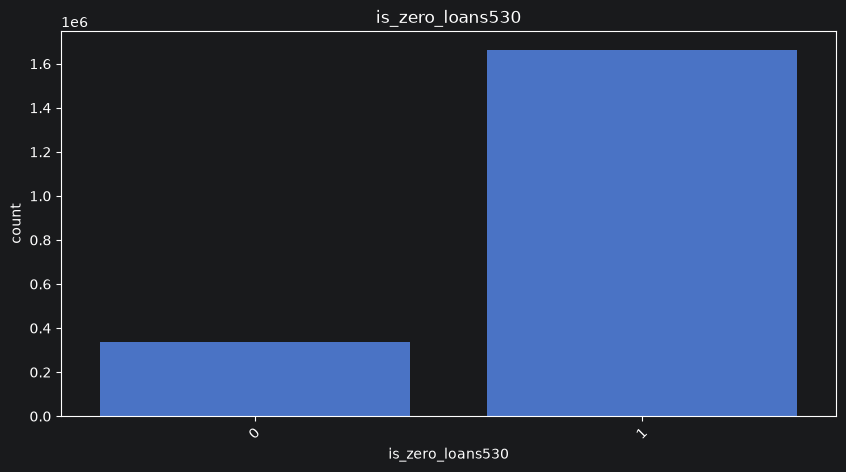

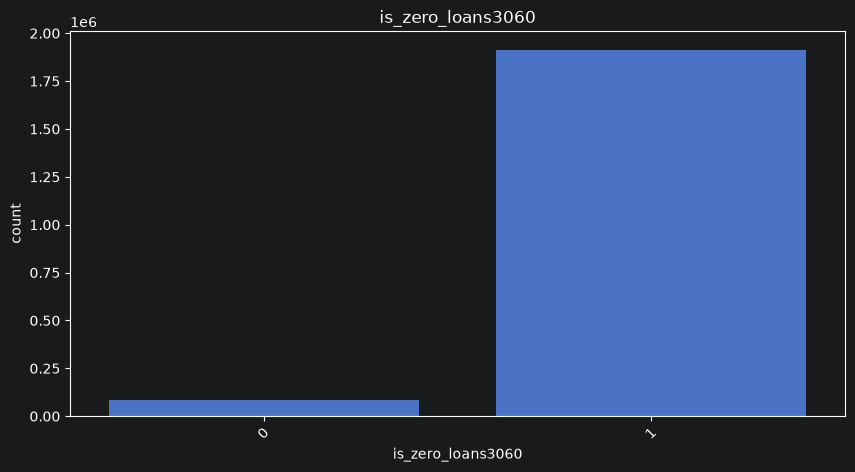

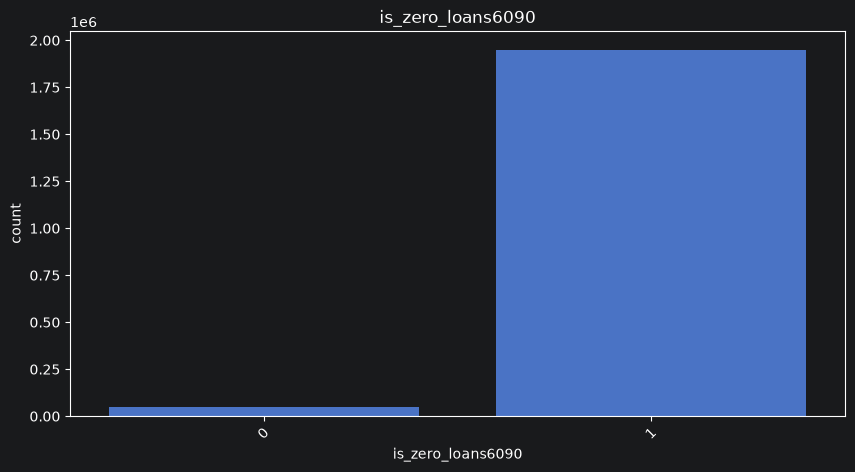

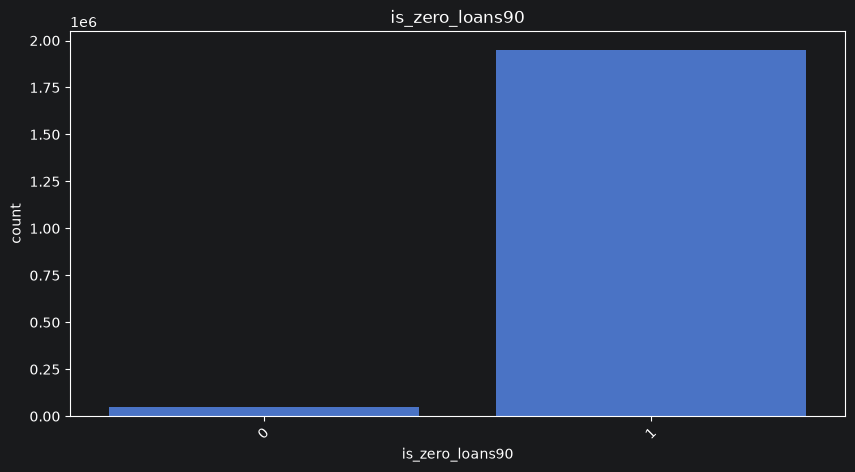

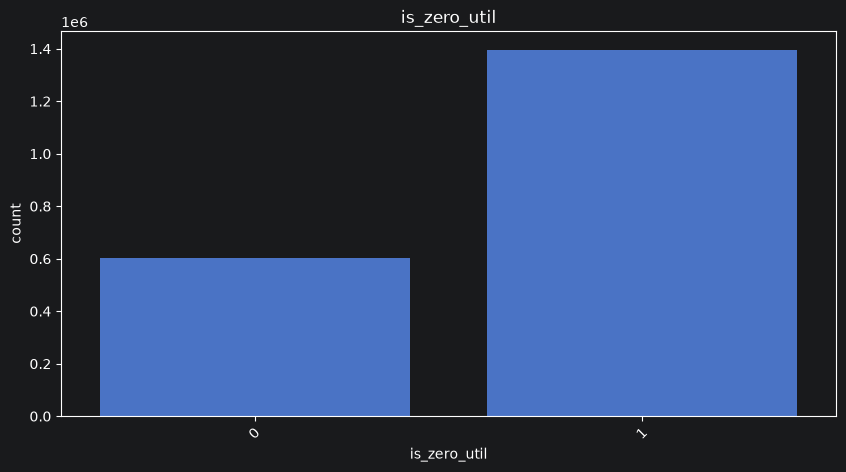

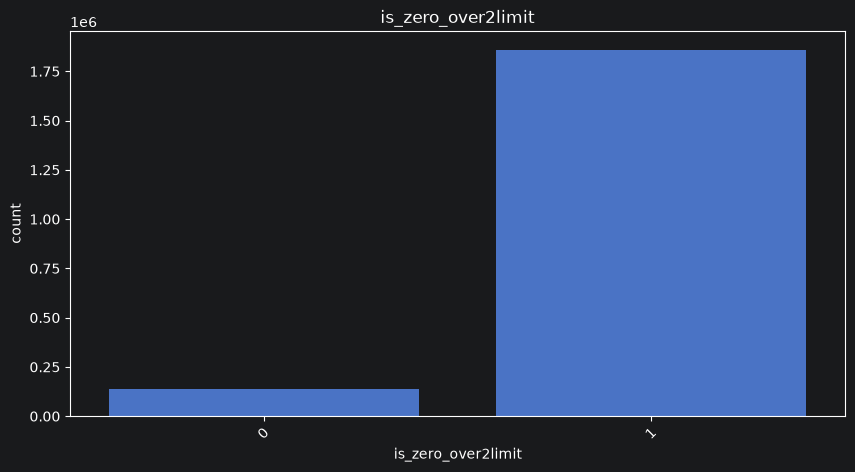

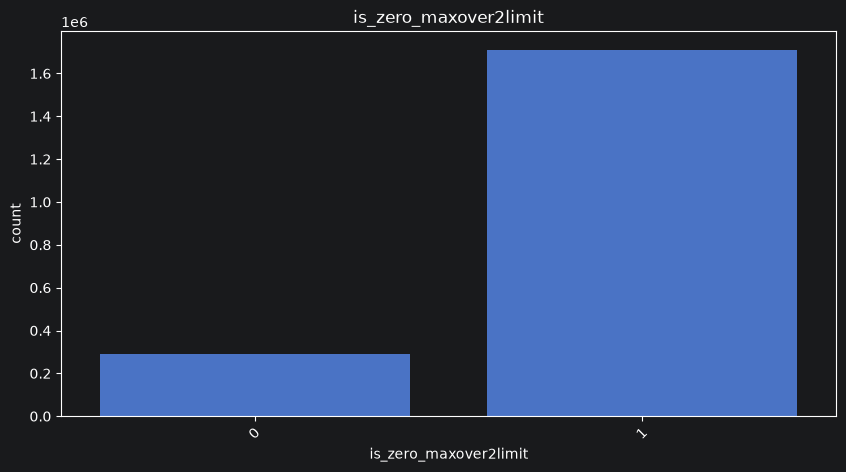

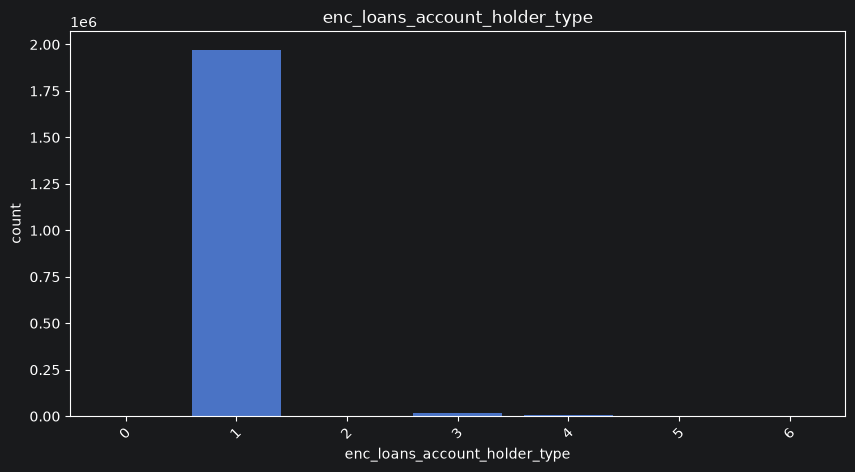

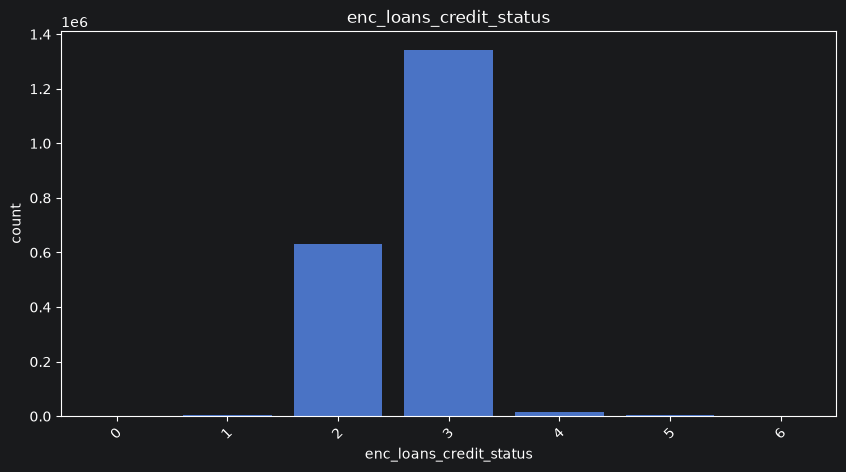

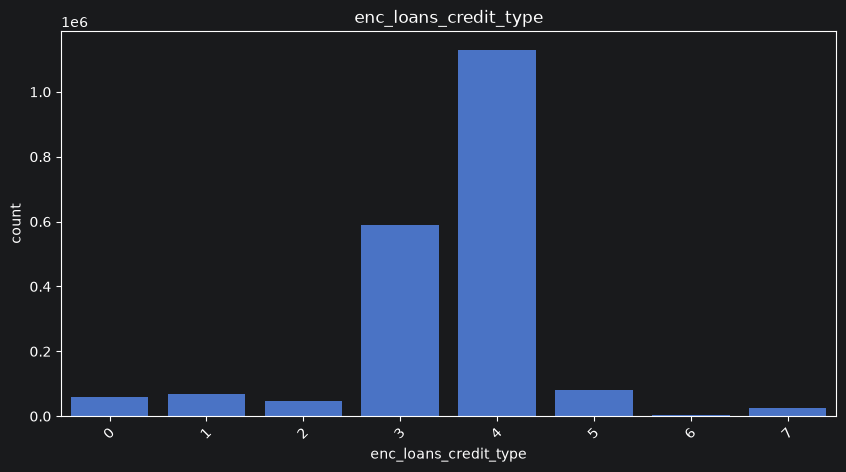

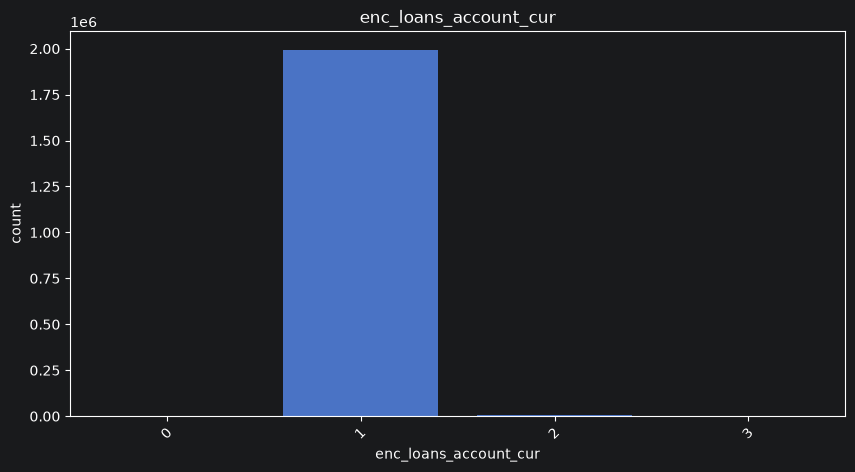

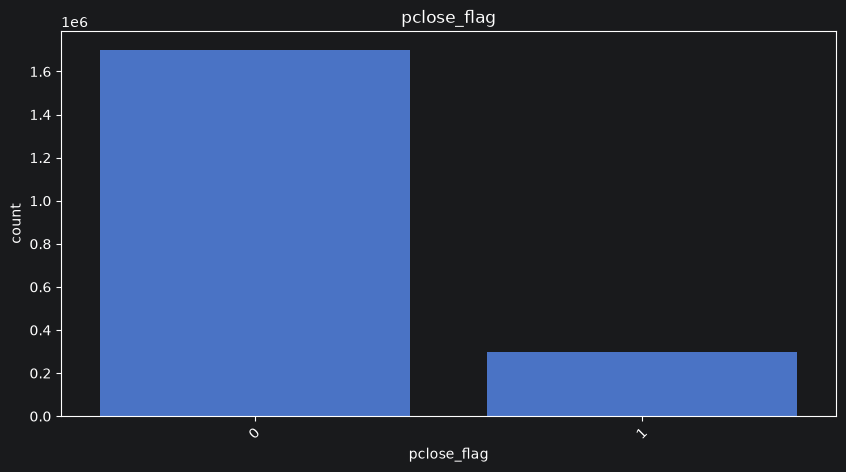

In [15]:
feature_distribution(df=data, features=categorical_features, categorical=True)

### Relations features / target

In [23]:
categorical_features = categorical_features + [ "pre_loans_next_pay_summ", "pre_loans_outstanding", "pre_loans_total_overdue"]
numerical_features.remove("pre_loans_next_pay_summ")
numerical_features.remove("pre_loans_outstanding")
numerical_features.remove("pre_loans_total_overdue")

In [37]:
def plot_relation_feature_target(df: pl.DataFrame, categorical: bool, features: list):
    if categorical:
        for feature in features:
            counts = (
                df.group_by([feature, "flag"])
                .len()
                .with_columns(
                    (pl.col("len") / pl.col("len").sum().over(feature) * 100)
                    .alias("percentage")
                )
                .to_pandas()
            )

            pivot_df = counts.pivot(
                index=feature, columns="flag",  values="percentage"
            ).fillna(0)

            plt.figure(figsize=(10, 6))
            pivot_df.plot(kind="bar", stacked=True, color=["#2ca02c", "#d62728"])
            plt.title(f"Proportion of default by category : {feature}")
            plt.ylabel("Percentage (%)")
            plt.xlabel(feature)
            plt.legend(title="Loan status")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

    else:
        for feature in features:
            plt.figure(figsize=(10, 8))
            sb.histplot(
                df.to_pandas(),
                x=feature,
                hue="flag",
                label="no default",
                palette={0: "green", 1: "red"},
                common_norm=False,
                discrete=True,
                stat="probability",
                multiple="dodge",
                shrink=0.8
            )
            plt.title(feature)
            plt.show()

#### Numerical features

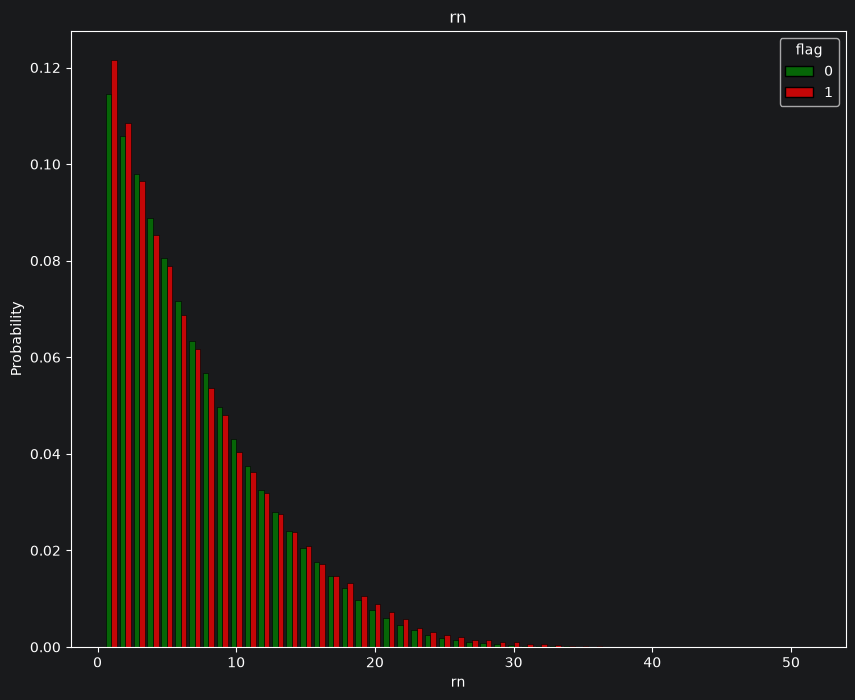

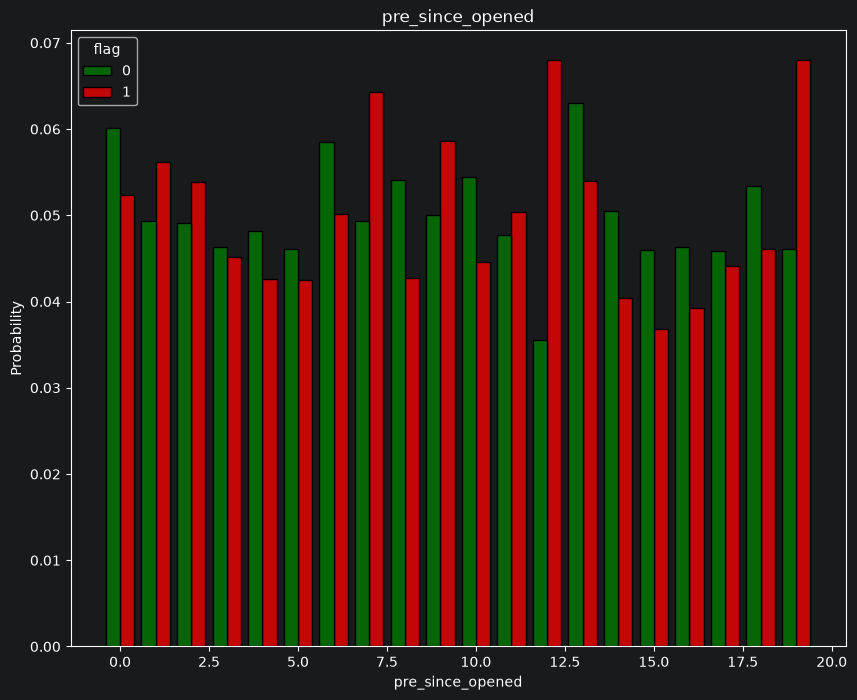

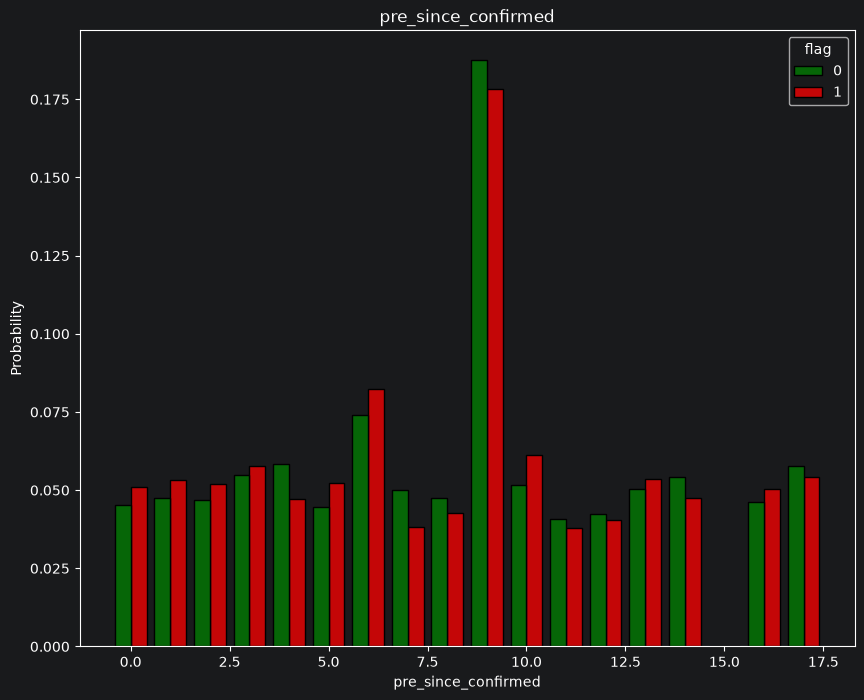

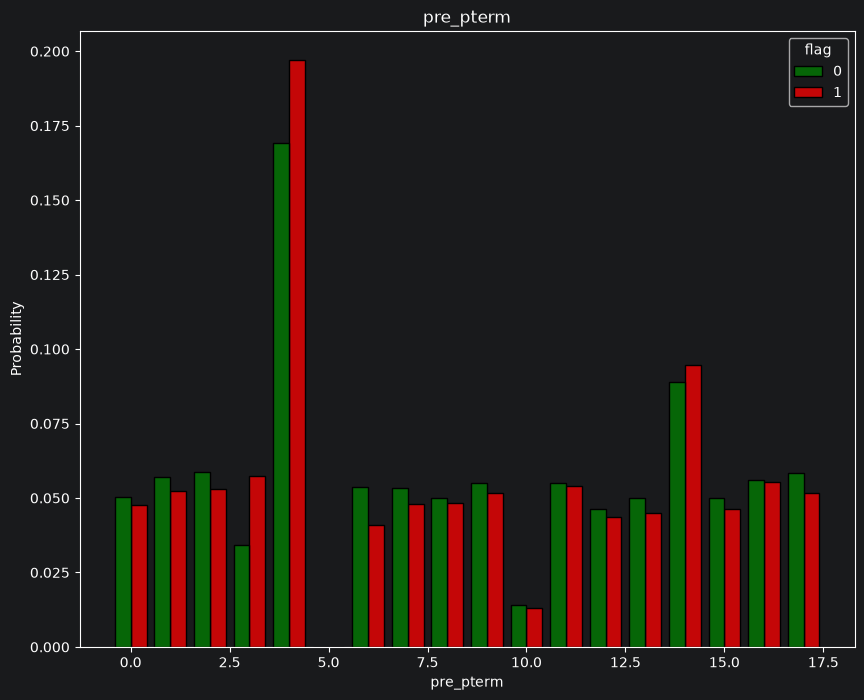

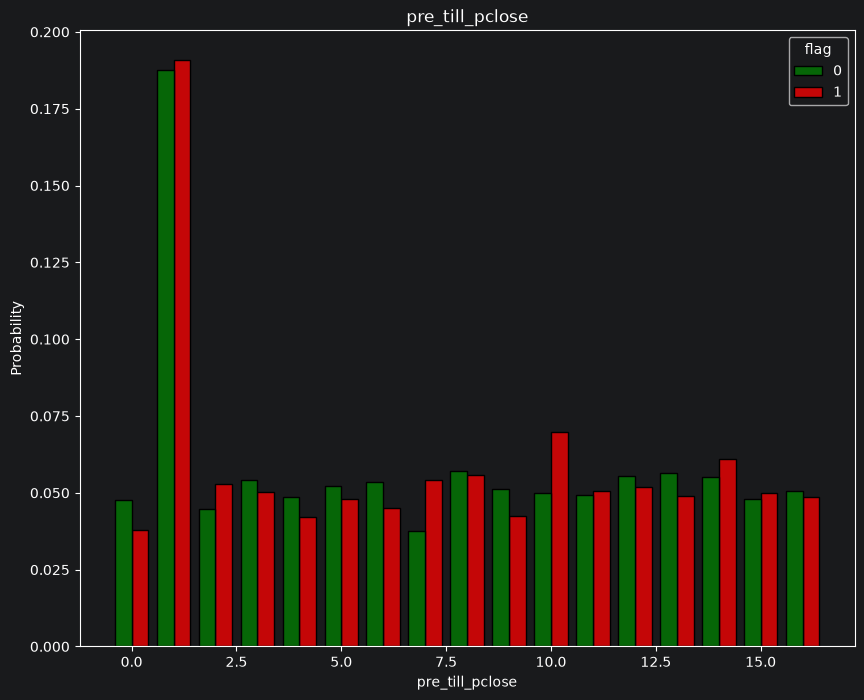

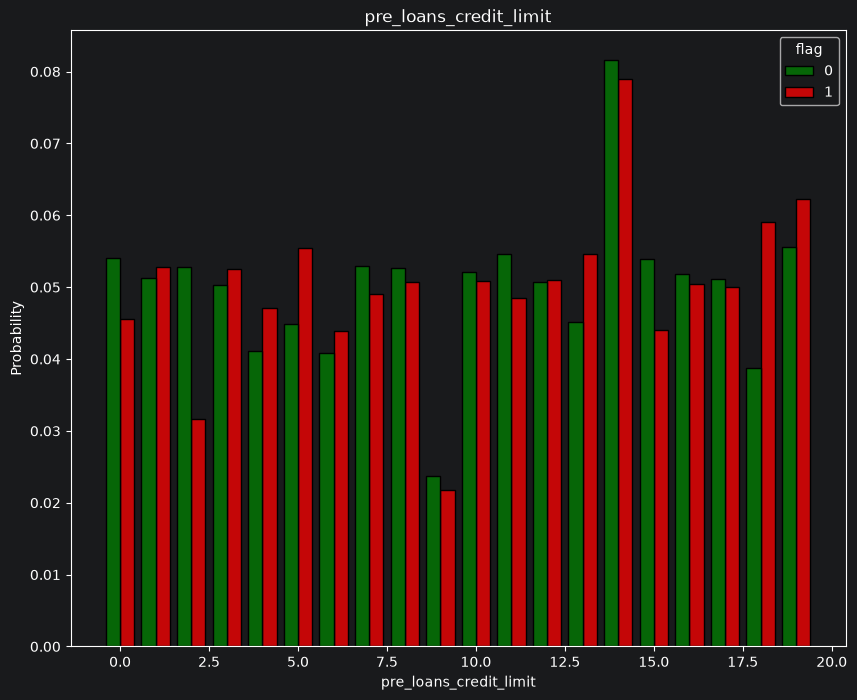

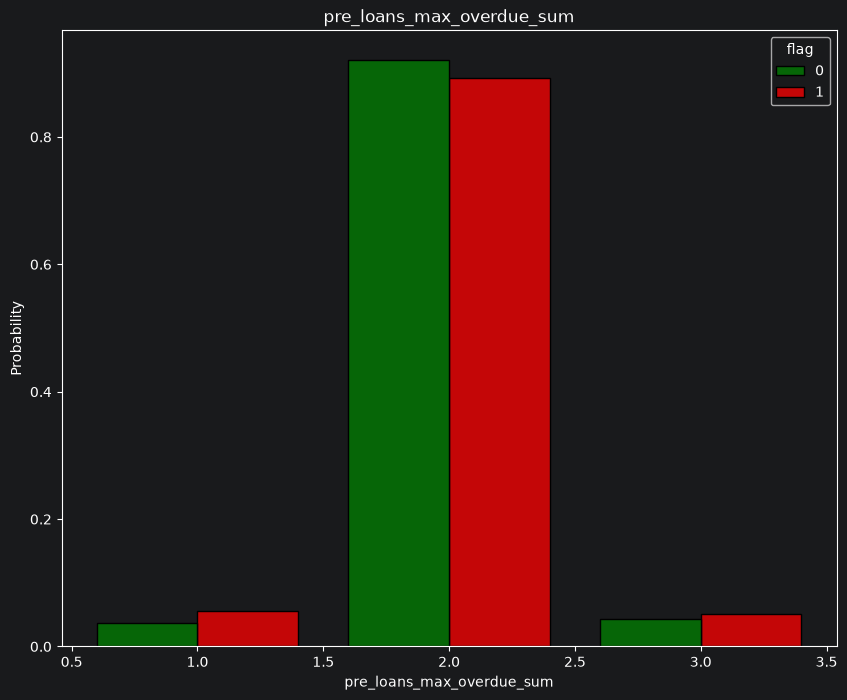

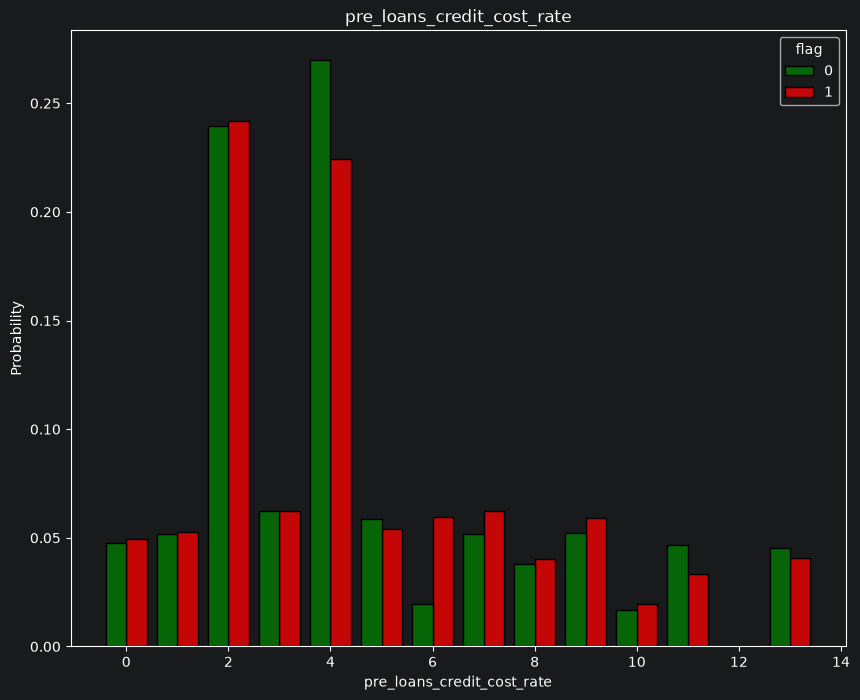

In [36]:
plot_relation_feature_target(df=data, categorical=False, features=numerical_features)

### Categorical features

<Figure size 1000x600 with 0 Axes>

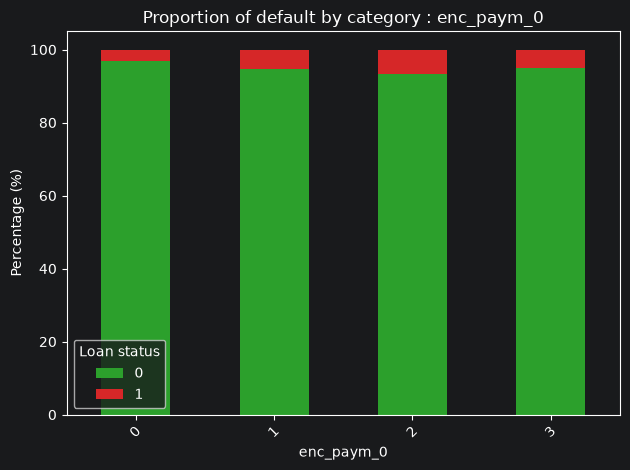

<Figure size 1000x600 with 0 Axes>

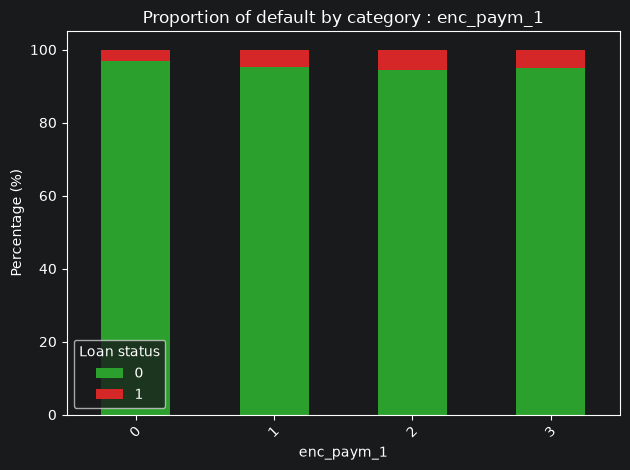

<Figure size 1000x600 with 0 Axes>

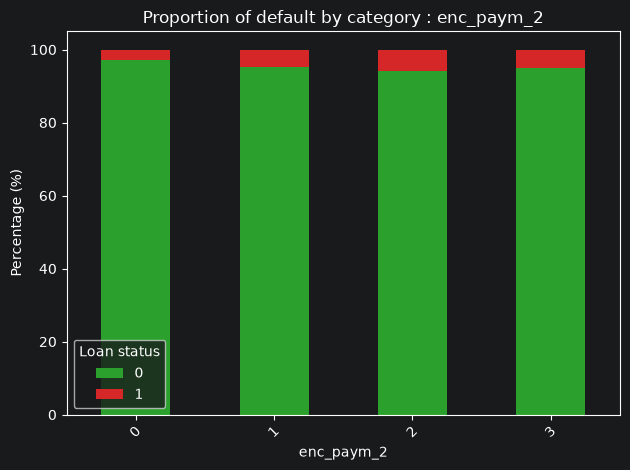

<Figure size 1000x600 with 0 Axes>

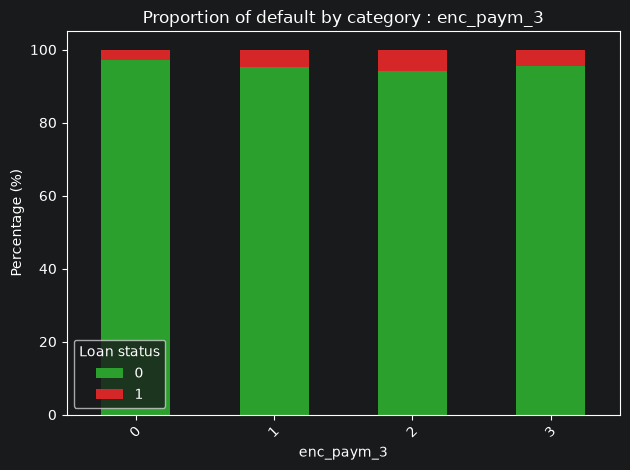

<Figure size 1000x600 with 0 Axes>

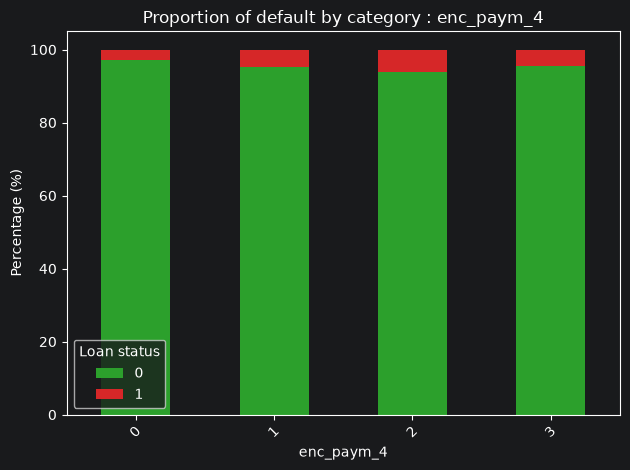

<Figure size 1000x600 with 0 Axes>

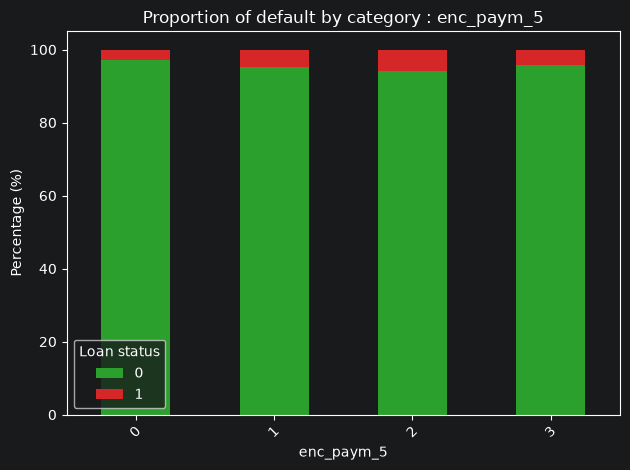

<Figure size 1000x600 with 0 Axes>

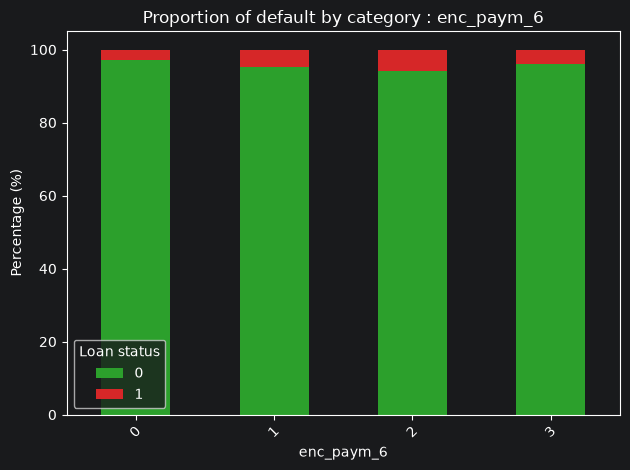

<Figure size 1000x600 with 0 Axes>

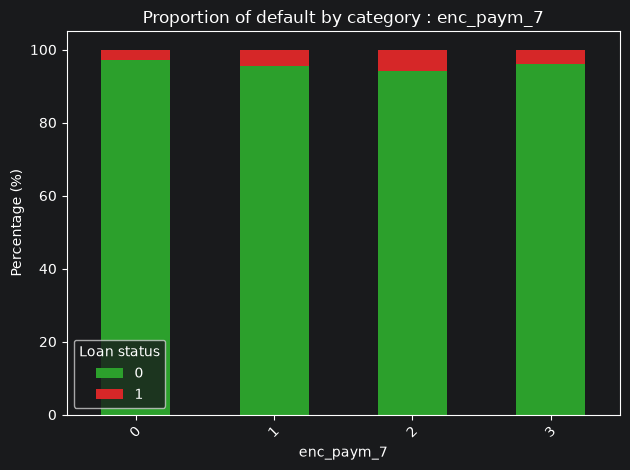

<Figure size 1000x600 with 0 Axes>

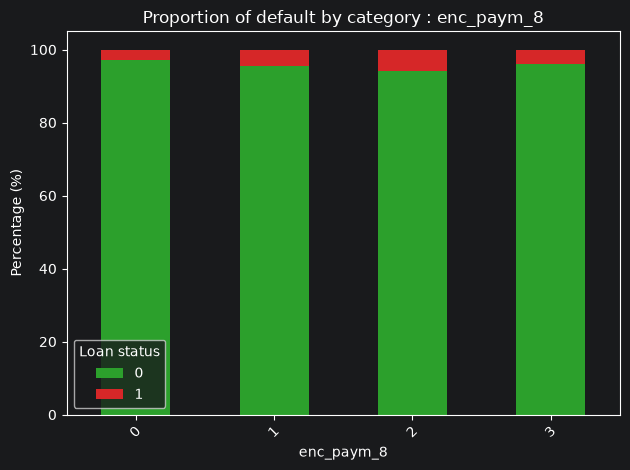

<Figure size 1000x600 with 0 Axes>

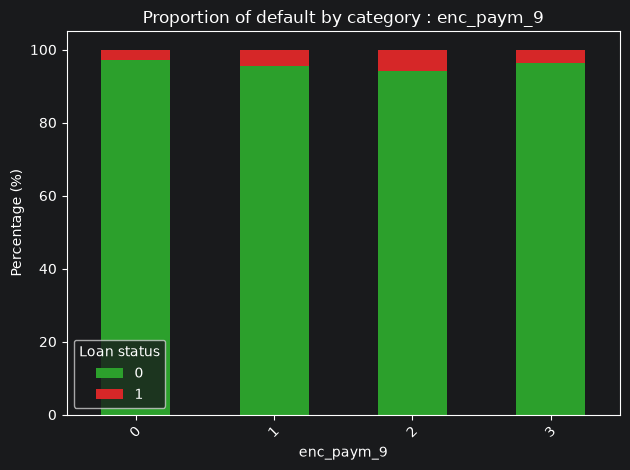

<Figure size 1000x600 with 0 Axes>

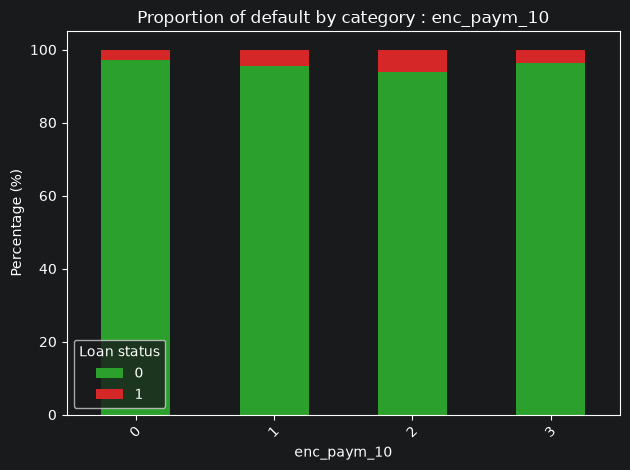

<Figure size 1000x600 with 0 Axes>

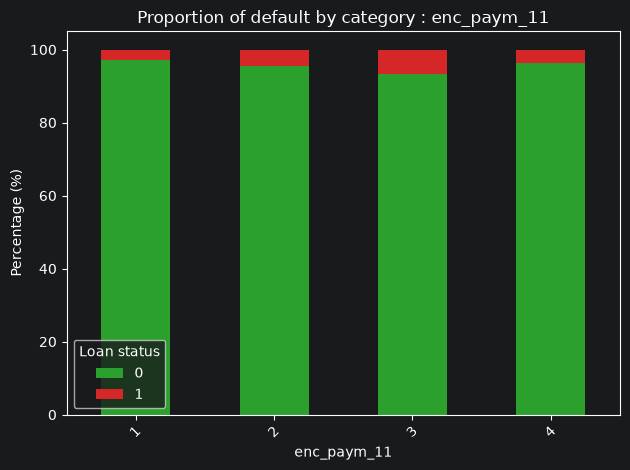

<Figure size 1000x600 with 0 Axes>

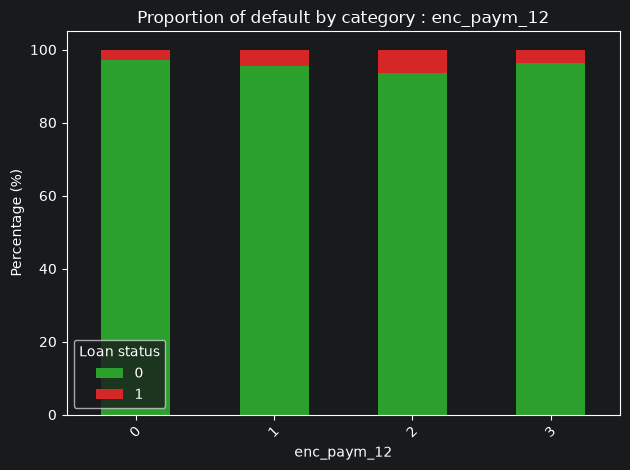

<Figure size 1000x600 with 0 Axes>

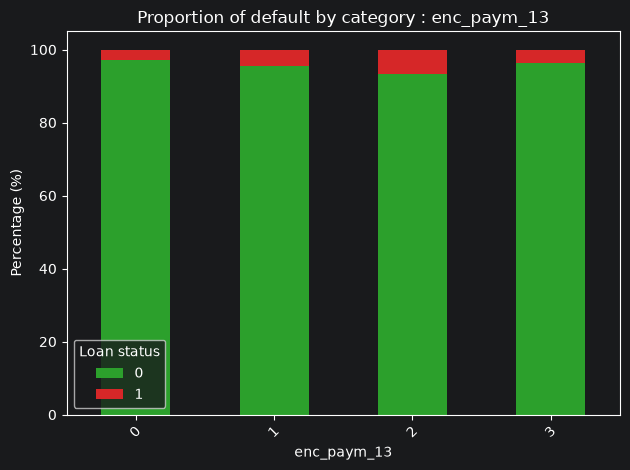

<Figure size 1000x600 with 0 Axes>

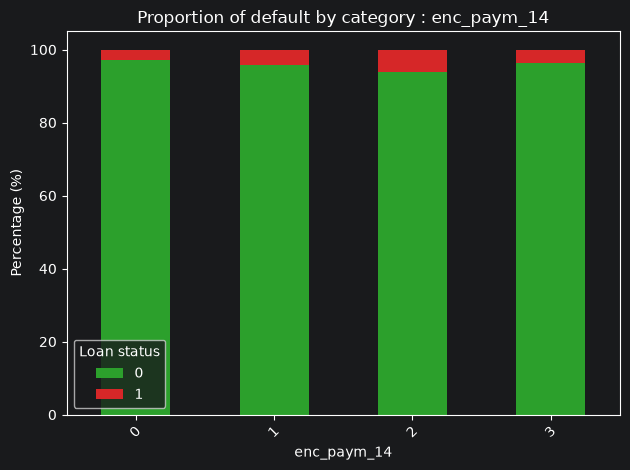

<Figure size 1000x600 with 0 Axes>

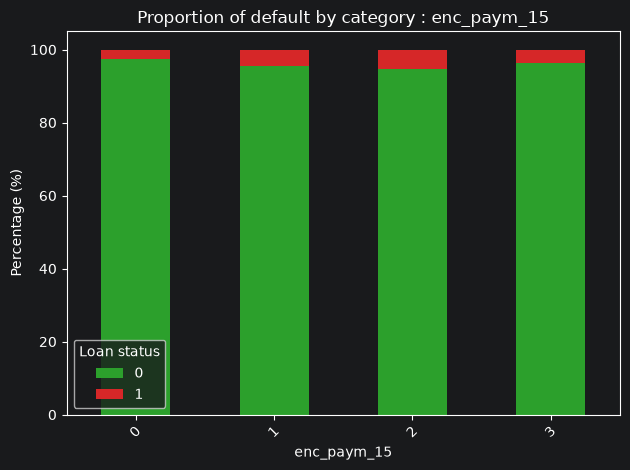

<Figure size 1000x600 with 0 Axes>

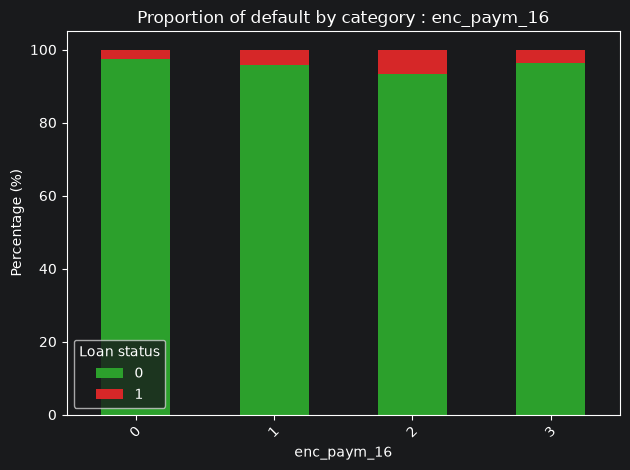

<Figure size 1000x600 with 0 Axes>

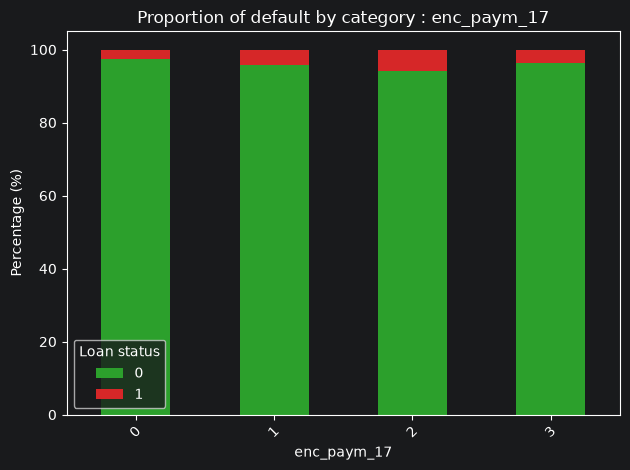

<Figure size 1000x600 with 0 Axes>

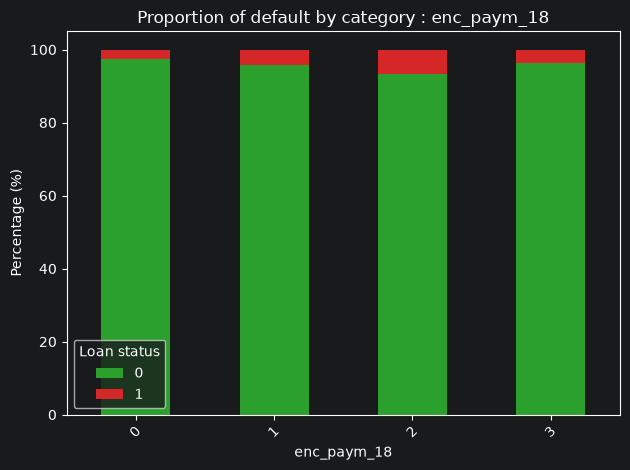

<Figure size 1000x600 with 0 Axes>

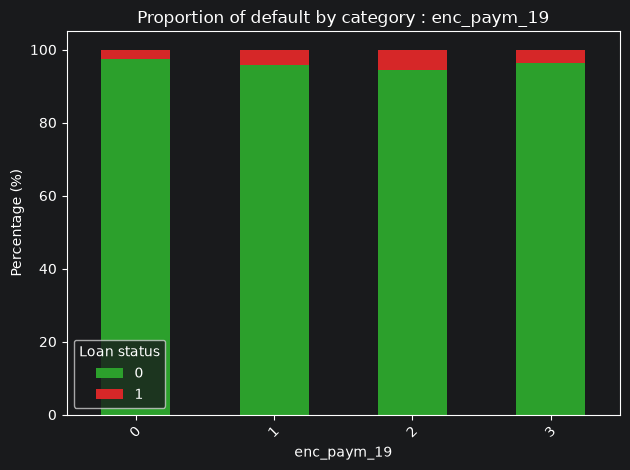

<Figure size 1000x600 with 0 Axes>

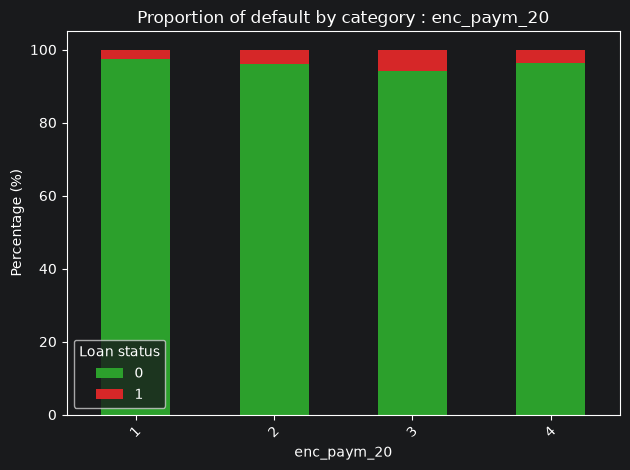

<Figure size 1000x600 with 0 Axes>

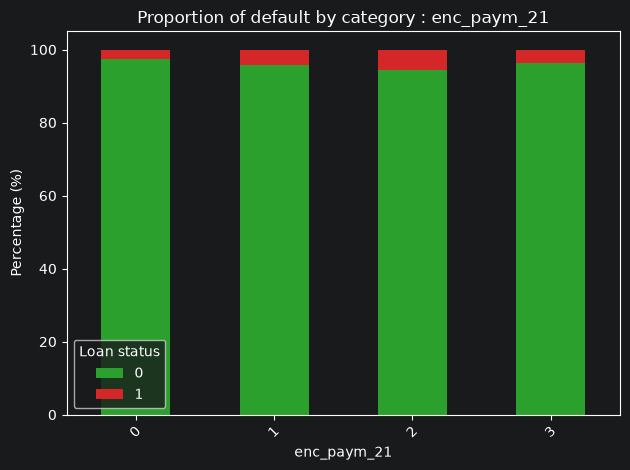

<Figure size 1000x600 with 0 Axes>

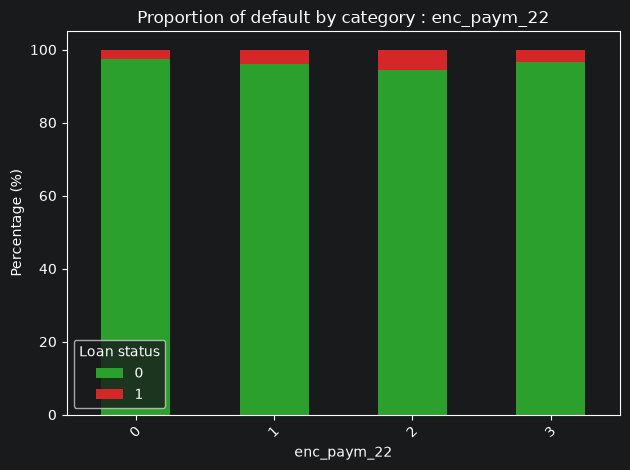

<Figure size 1000x600 with 0 Axes>

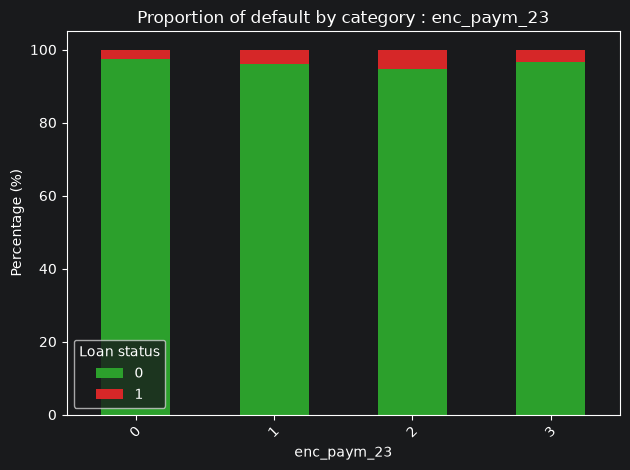

<Figure size 1000x600 with 0 Axes>

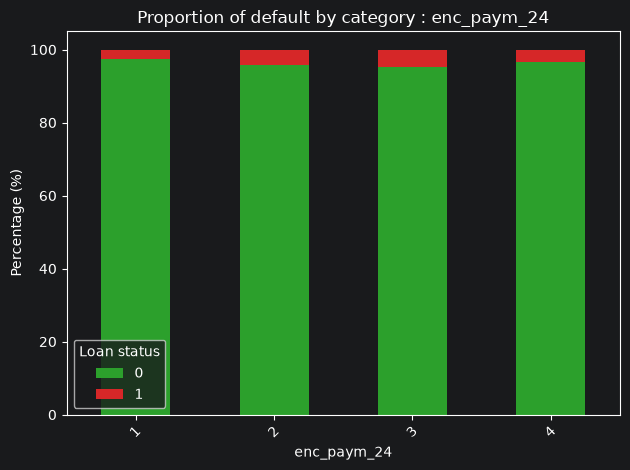

<Figure size 1000x600 with 0 Axes>

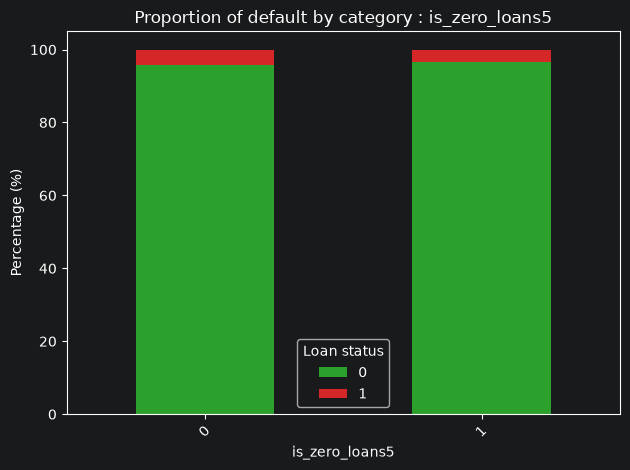

<Figure size 1000x600 with 0 Axes>

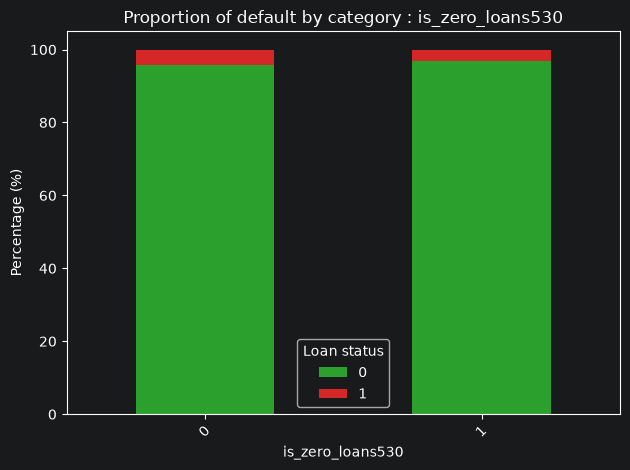

<Figure size 1000x600 with 0 Axes>

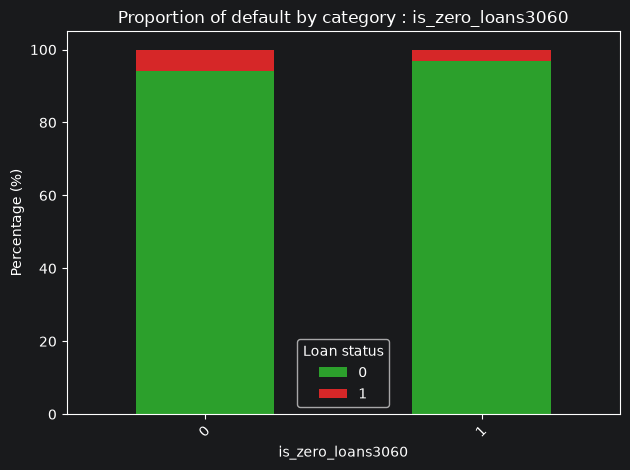

<Figure size 1000x600 with 0 Axes>

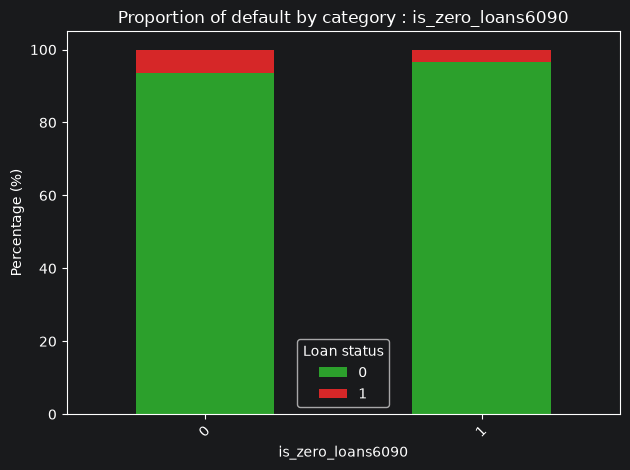

<Figure size 1000x600 with 0 Axes>

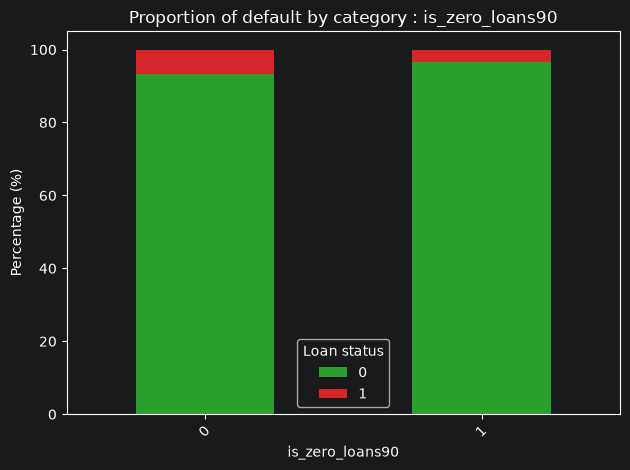

<Figure size 1000x600 with 0 Axes>

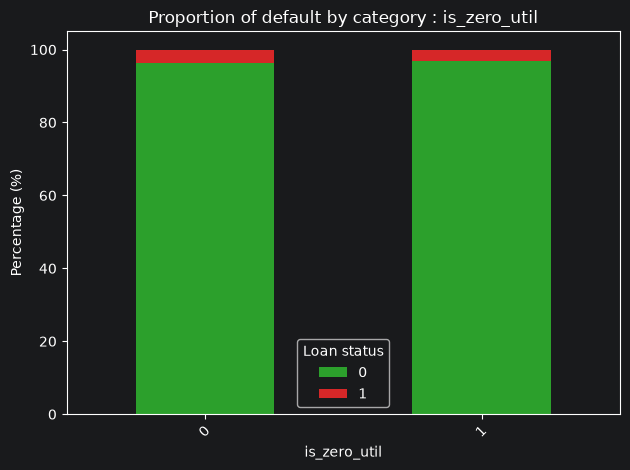

<Figure size 1000x600 with 0 Axes>

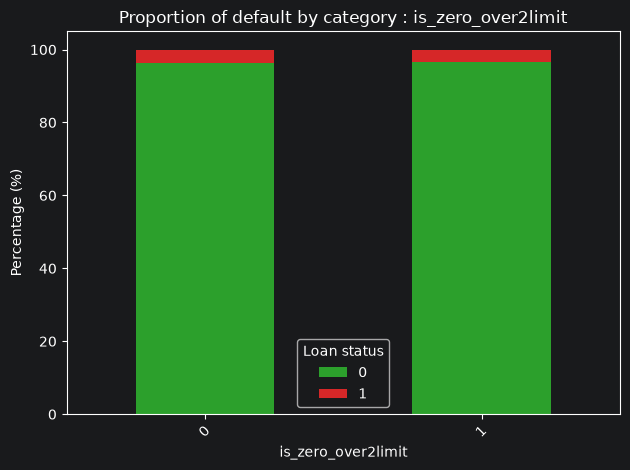

<Figure size 1000x600 with 0 Axes>

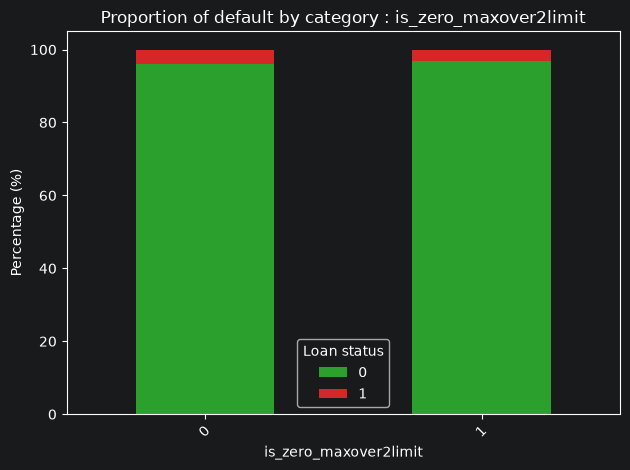

<Figure size 1000x600 with 0 Axes>

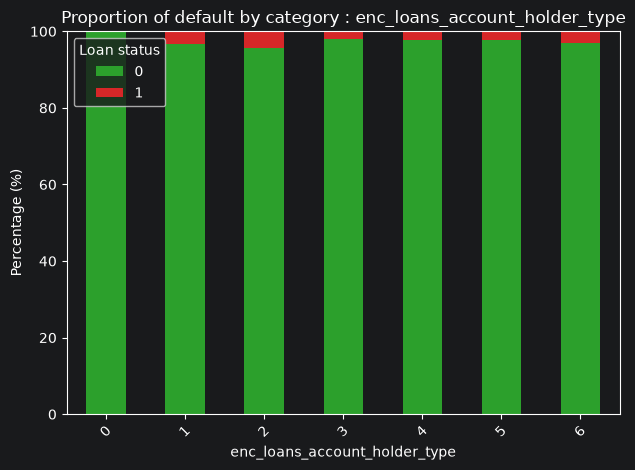

<Figure size 1000x600 with 0 Axes>

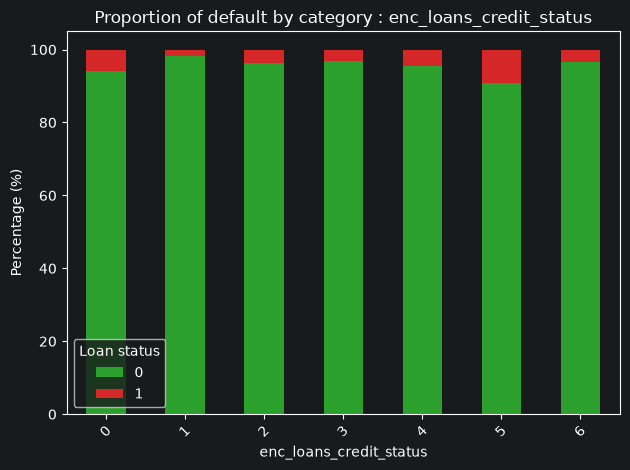

<Figure size 1000x600 with 0 Axes>

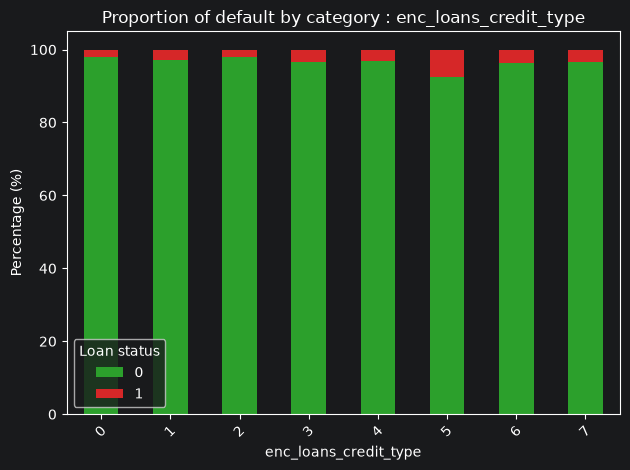

<Figure size 1000x600 with 0 Axes>

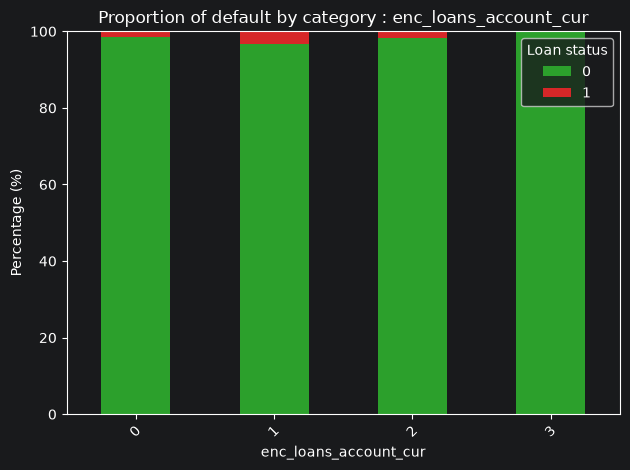

<Figure size 1000x600 with 0 Axes>

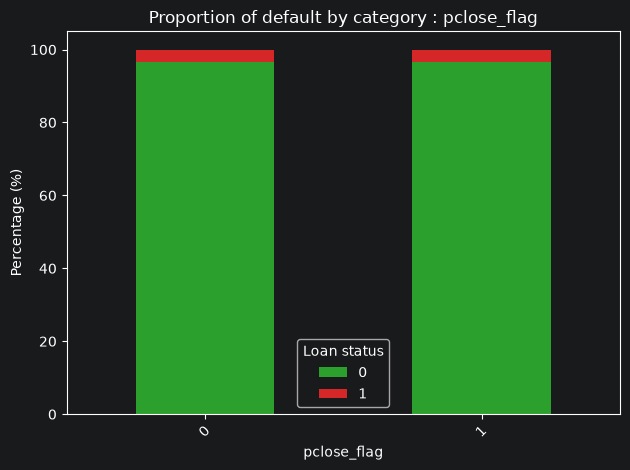

<Figure size 1000x600 with 0 Axes>

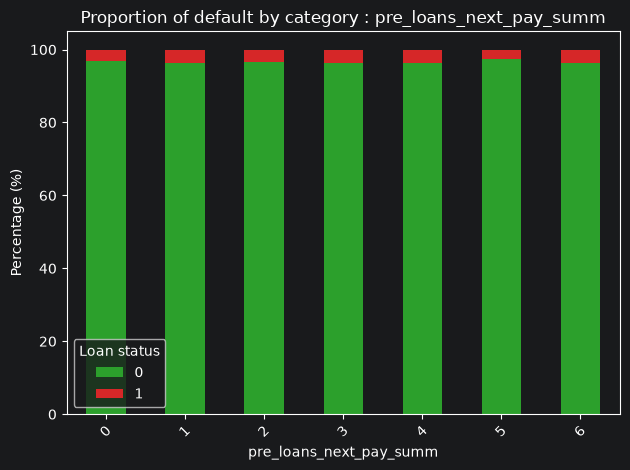

<Figure size 1000x600 with 0 Axes>

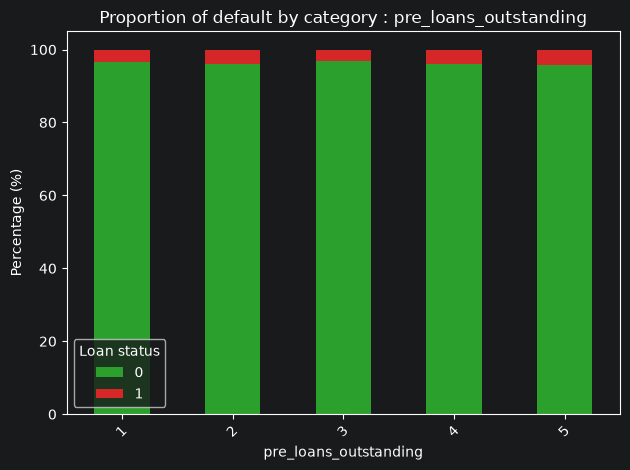

<Figure size 1000x600 with 0 Axes>

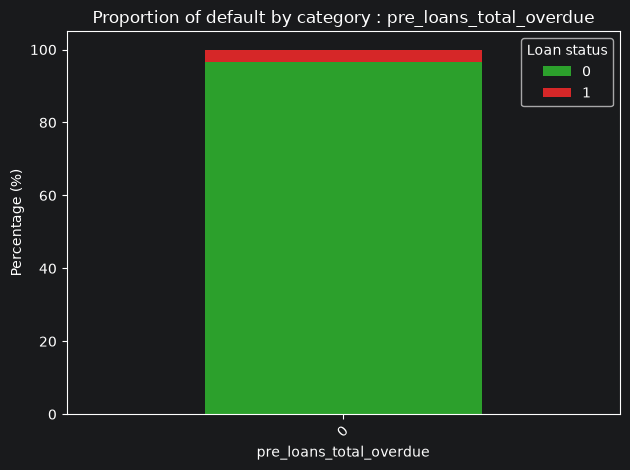

<Figure size 1000x600 with 0 Axes>

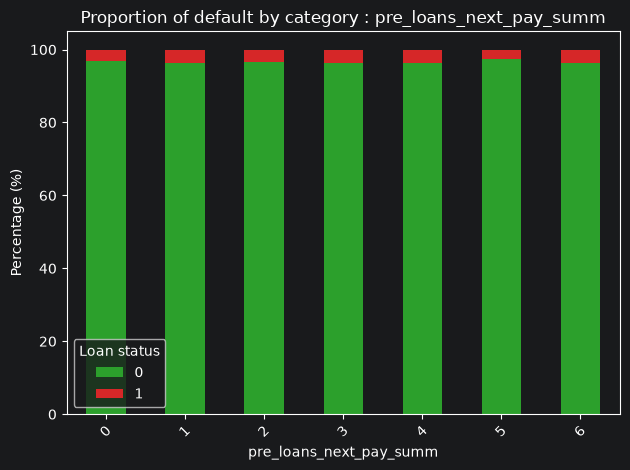

<Figure size 1000x600 with 0 Axes>

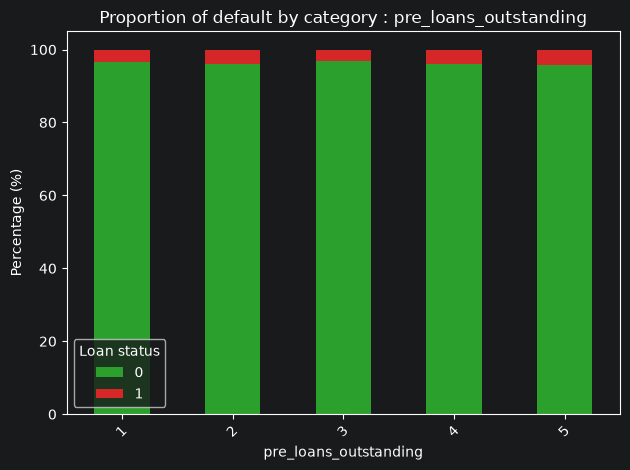

<Figure size 1000x600 with 0 Axes>

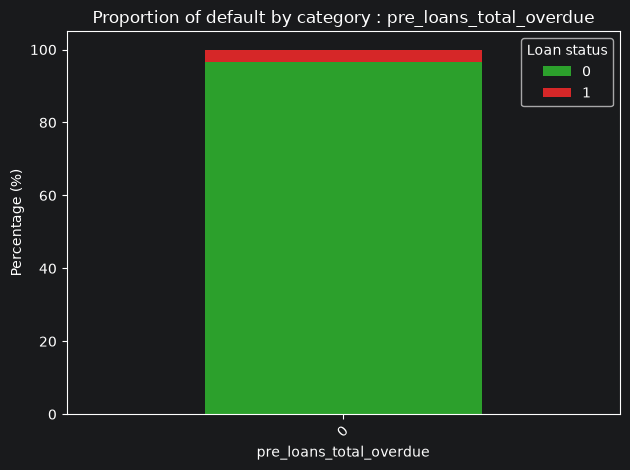

In [38]:
plot_relation_feature_target(df=data, categorical=True, features=categorical_features)

In [ ]:
paym_cols = [c for c in data.columns if c.startswith("enc_paym_")]

df_aggregated = data.with_columns(
    # Pire statut de paiement jamais atteint
    pl.max_horizontal(paym_cols).alias("paym_max_status"),
    # Statut moyen sur toute la période
    pl.concat_list(paym_cols)
    .list.eval(pl.element().mean())
    .list.first()
    .alias("paym_mean_status"),
    # Nombre de mois avec des retards / incidents (supposons > 0)
    pl.concat_list(paym_cols)
    .list.eval((pl.element() > 0).sum())
    .list.first()
    .alias("paym_count_incidents"),
    # Dernier statut connu (ex: le mois le plus récent enc_paym_0)
    pl.col("enc_paym_0").alias("paym_latest_status"),
)